# Séries temporelles — support des slides et TP

## Objectifs

1. **Construire** un problème de prévision avec des informations réellement disponibles.
2. **Diagnostiquer** composantes, défauts, retards et hypothèses de stationnarité.
3. **Implémenter et appliquer** références, lissage exponentiel, AR/ARIMA et régression temporelle.
4. **Comparer** des prévisions avec une validation adaptée au temps.
5. **Interpréter** erreurs, résidus, couverture et limites d’une bande de prévision.
6. **Justifier** un protocole complet et reproductible.

## Préparation

Python : variables, boucles, fonctions, tableaux et graphiques. Les rappels nécessaires sont donnés dans chaque section.
Depuis `cours/` : `python -m pip install -r requirements.txt`, puis `python -m jupyterlab notebook.ipynb`.
Les sections M03 à M09 possèdent leurs ressources indépendantes : exécutez d’abord les imports ci-dessous, puis la cellule « Ressources fournies » du module choisi. Les exercices précédents n’ont pas à être complétés pour démarrer un nouveau module.

Les données sont **simulées** ; graines fixées, petits tableaux, CPU, aucun GPU. Ne pas interpréter les performances comme celles d’un capteur réel.
Une cellule « À compléter » affiche « non vérifié » jusqu’à votre réponse. Le code fourni autour des trous n’est pas l’objet de l’exercice.

## Parcours

**Parcours principal :** M01 problème temporel → M02 signal → M03 autocorrélation et stationnarité → M04 AR/ARIMA → M05 lissage exponentiel → M06 comparaison et incertitude.

**Compléments :** M07 évaluation → M08 tendance et saisonnalité → M09 régression et calendrier.

Les sections **« Support des slides »** rassemblent les rappels et les exemples fournis : elles ne demandent pas une activité supplémentaire. Les exercices identifiés EX-03 à EX-24 demandent du code, une expérience ou une interprétation selon leur consigne. EX-04 est une expérimentation avec du code fourni.


## Plan de lecture — support des slides et TP séparés

La présentation et ce notebook suivent **M01 → M02 → M03 → M04 → M05 → M06**, puis les compléments **M07 → M08 → M09**.

| Module | Sujet |
|---|---|
| **M01** | Poser un problème temporel |
| **M02** | Explorer et préparer un signal |
| **M03** | Autocorrélation et stationnarité |
| **M04** | Modéliser la dépendance au passé |
| **M05** | Quel poids donner au passé ? |
| **M06** | Comparer les prévisions et décrire leur incertitude |
| **M07** | Évaluer une prévision · complément |
| **M08** | Tendance et saisonnalité · complément |
| **M09** | Prédire avec les valeurs passées et le calendrier · complément |

Les repères **TP/EX/ACT** sont des identifiants stables, indépendants des numéros de modules. « Support des slides » désigne un exemple fourni. Les exercices restent une pratique séparée.

Le cas principal de **M06** est une demande quotidienne simulée à H = 1. **TP-08** est une extension à H = 6 sur température simulée, avec régression : à explorer après **M09**. Ses ressources sont fournies ; ses scores ne sont pas ceux de la présentation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.outil_ts import (signal_long, acf_simple, reference, mae, rmse,
    niveau_ses, design, fit_ridge, predict_ridge, optional_statsmodels)
SEED = 2026
plt.rcParams.update({'figure.figsize': (9, 3.5), 'axes.spines.top': False,
                     'axes.spines.right': False})
print('Imports prêts. Chaque exemple précise son pas de temps.')

## 1. M01 — Poser un problème temporel · TP-01

**Dans ce TP :** décrire la cible et construire plusieurs couples passé → futur sans inclure une mesure inconnue.

### 1.1 Données et notation — code fourni

Une observation peut être repérée par son indice : x[t]. Cet indice peut exister sans date connue. Dans notre exemple, les observations sont horaires : Δt=1 h. L’indice commence à zéro. À l’origine t, x[t] est déjà observé ; la cible est x[t+H].

**t** : dernier indice connu · **p** : nombre d’observations gardées · **H** : nombre de pas jusqu’à la cible.

Tracez la série avec la cellule suivante. Le futur est affiché pour observer ce qui s’est passé ; ne l’utilisez pas pour construire vos prévisions.

In [ ]:
t = np.arange(96)
trend = 18 + 0.025 * t
seasonal = 2 * np.sin(2 * np.pi * t / 24)
noise = np.random.default_rng(SEED).normal(0, 0.8, len(t))
x_reference = trend + seasonal + noise
fig, ax = plt.subplots()
ax.plot(t[:60], x_reference[:60], label='Passé connu à t=59')
ax.plot(t[60:], x_reference[60:], '--', color='gray', label='Futur révélé après coup')
ax.axvline(59, color='darkorange', linestyle=':')
ax.set(xlabel='Temps (heures)', ylabel='Température simulée (°C)')
ax.legend(); plt.show()
assert x_reference.shape == (96,) and np.isfinite(x_reference).all()


### Support des slides · ACT-01 — Horizon et durée

**Durée = H × Δt**, pour un pas constant.

Une observation par heure : **6 × 1 h = 6 h**.

Une observation par dix minutes : **6 × 10 min = 60 min = 1 h**.

Six pas comptent six intervalles entre la dernière observation et la cible.


### Support des slides · ACT-02 — Des règles aux prévisions, puis aux erreurs

À l’origine **t = 59**, les cibles sont x[60] pour H = 1 et x[65] pour H = 6. Seules les mesures jusqu’à x[59] sont connues.

| Règle | Calcul à H = 1 | Calcul à H = 6 |
|---|---|---|
| Dernière valeur (naïf) | x[59] | x[59] |
| Moyenne récente | moyenne de x[54:60] | même moyenne |
| Même heure la veille (saisonnier) | x[36] | x[41] |

La règle saisonnière reprend l’heure de la **cible** la veille. Le premier graphique montre les températures prédites depuis le même instant 59, aux horizons 1 à 6. Les mesures futures sont révélées uniquement pour comparer après coup ; elles ne servent pas à prévoir.

Le naïf et la moyenne donnent chacun une ligne horizontale depuis cette origine. Le saisonnier reprend le motif observé la veille. À H=1 le saisonnier est le plus proche ; à H=6 le naïf est plus proche. La cellule est fournie, sans code à compléter.


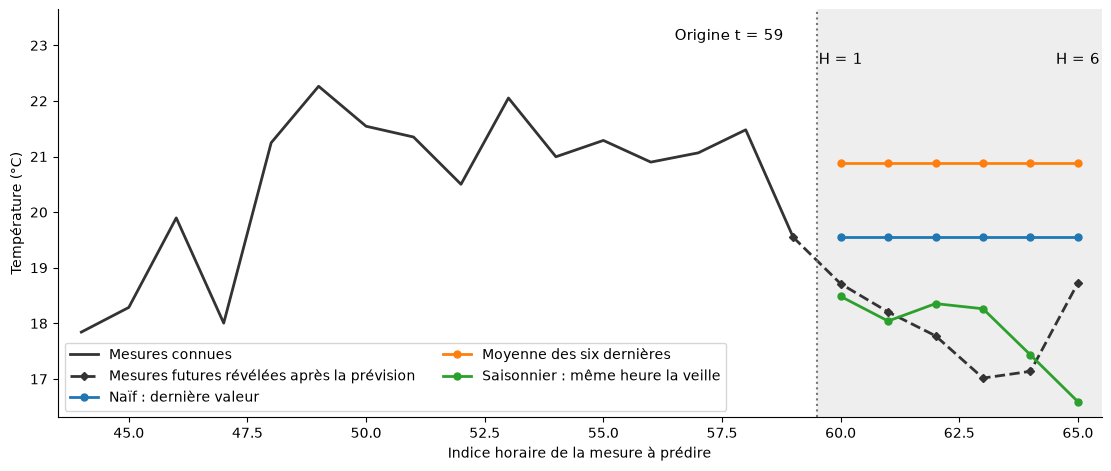

In [3]:
# Fourni : afficher ce que les trois règles prédisent depuis t=59.
from scripts.generer_figures_act02 import previsions_origine, previsions_repetees, COLORS
x_act = 18 + .025*np.arange(96) + 2*np.sin(2*np.pi*np.arange(96)/24)
x_act += np.random.default_rng(2026).normal(0,.8,96)
fig = previsions_origine(x_act, origine=59)
plt.show()


#### ACT-02 — Comparer aux mesures et répéter à plusieurs instants

Une **erreur absolue** est la distance entre la température prédite et la mesure reçue ensuite, au même indice cible. À H=6 depuis t=59 : |19,548 − 18,728| ≈ 0,820 °C pour le naïf.

La cellule affiche les valeurs et les écarts à cette origine, puis refait les prévisions aux **66 origines de 24 à 89**. Chaque point du deuxième graphique est une nouvelle prévision, émise H pas avant sa cible. La courbe naïve varie donc : sa dernière mesure change à chaque nouveau départ.

À H=6, le saisonnier suit mieux le motif quotidien dans cet exemple, sans gagner à chaque instant. À l’indice 65, le naïf reste plus proche.


H=1 ; mesure à l'indice 60 : 18.712 °C
  naif : prévision 19.548 °C ; erreur 0.836 °C
  moyenne : prévision 20.880 °C ; erreur 2.168 °C
  saisonnier : prévision 18.485 °C ; erreur 0.227 °C
H=6 ; mesure à l'indice 65 : 18.728 °C
  naif : prévision 19.548 °C ; erreur 0.820 °C
  moyenne : prévision 20.880 °C ; erreur 2.152 °C
  saisonnier : prévision 16.591 °C ; erreur 2.137 °C


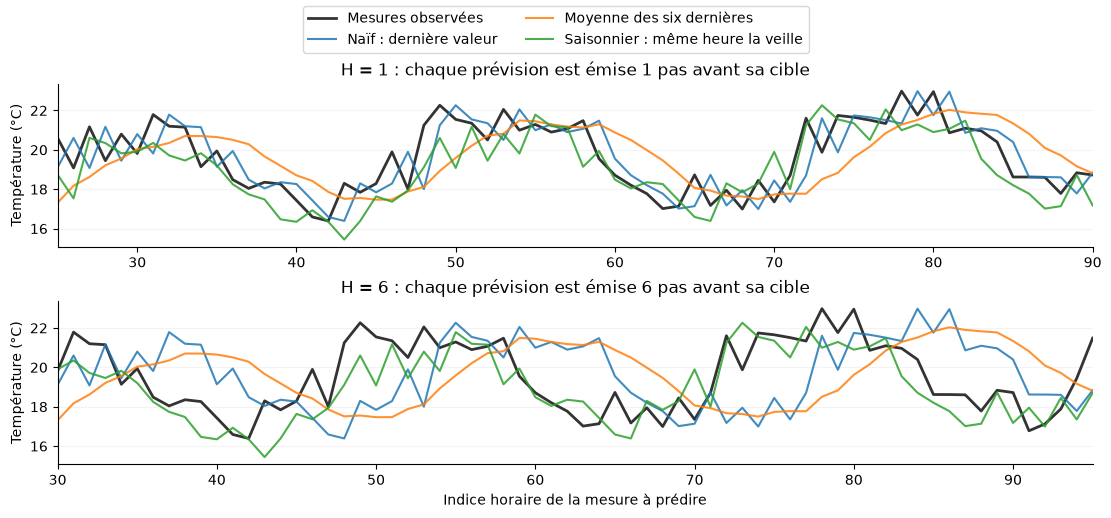

In [4]:
# Fourni : valeurs prédites et erreurs à la même origine.
for h in [1, 6]:
    print(f"H={h} ; mesure à l'indice {59+h} : {x_act[59+h]:.3f} °C")
    for method in ['naif', 'moyenne', 'saisonnier']:
        prediction = reference(x_act, [59], h, method)[0]
        erreur = abs(prediction-x_act[59+h])
        print(f"  {method} : prévision {prediction:.3f} °C ; erreur {erreur:.3f} °C")
orig_act = np.arange(24, 90)
fig = previsions_repetees(x_act, orig_act)
plt.show()


#### ACT-02 — Résumer les erreurs : la MAE

À horizon fixé, on calcule l’écart absolu sur chacune des 66 prévisions, puis on fait la moyenne. Cette moyenne est la **MAE** ; elle s’exprime ici en °C. Le dernier graphique affiche donc des erreurs moyennes, tandis que les graphiques précédents affichaient des températures.

À H=1, naïf et saisonnier sont presque égaux en moyenne ; à H=6, le saisonnier gagne sur cette simulation. Une bonne prévision isolée ne suffit pas à classer les méthodes. Sans motif quotidien, le classement peut changer. Seuls les horizons 1 et 6 sont calculés ici : le segment qui relie les scores ne donne pas les scores intermédiaires.


naif MAE H=1 / H=6 : [1.001 1.979]
moyenne MAE H=1 / H=6 : [1.315 2.446]
saisonnier MAE H=1 / H=6 : [1.001 1.015]


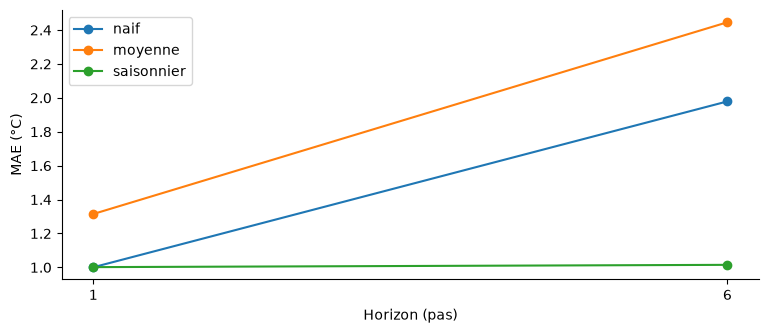

In [5]:
# Fourni : moyenne des écarts sur les mêmes 66 origines pour chaque règle.
fig, ax = plt.subplots(figsize=(9, 3.5))
for method in ['naif', 'moyenne', 'saisonnier']:
    scores = [mae(x_act[orig_act+h], reference(x_act, orig_act, h, method)) for h in [1,6]]
    print(method, 'MAE H=1 / H=6 :', np.round(scores,3))
    ax.plot([1,6], scores, 'o-', color=COLORS[method], label=method)
ax.set(xlabel='Horizon (pas)', ylabel='MAE (°C)', xticks=[1,6])
ax.legend()
plt.show()


### Support des slides · ACT-03 — À retenir : disponibilité des données

Une donnée peut figurer dans le fichier final sans avoir été disponible au moment de la prévision.

- Vérifiez **l’heure de réception ou de publication**, pas seulement l’heure de la mesure.
- Conservez **la version connue à cet instant** : une révision publiée plus tard appartient au futur.
- Une transformation des entrées doit utiliser **des valeurs déjà connues**. Une moyenne centrée qui lit une mesure future crée une fuite.

**Fuite d’information** : utiliser pour prévoir une donnée qui n’était pas encore disponible.

Exemple : à 18 h, une prévision météo publiée à 17 h peut être utilisée ; une mesure reçue à 18 h 15 et une révision publiée à 18 h 30 doivent être exclues.


### 1.2 TP-01 — Du tableau à un diagnostic de fuite

EX-01 et EX-02 sont des exemples fournis sur les fenêtres : lisez le calcul et exécutez les cellules pour voir leur alignement. **EX-03 · 15 min** : examinez le programme trompeur, corrigez l’entrée et expliquez ce que les tests vérifient. Travail en binôme ; le TP se fait dans un temps de pratique séparé.

### Support des slides · EX-01 — Une fenêtre et sa cible

**Exemple fourni : aucune cellule à compléter ici.**

Pour `toy = [3, 5, 4, 8, 7, 9, 6, 10]`, à **t = 4**, on connaît les indices 0 à 4. Avec **p = 3**, on garde les indices **2, 3, 4**, soit **[4, 8, 7]**. Avec **H = 1**, la cible est à l’indice **5**, soit **9**.

`t` est le dernier indice connu ; `p` compte les observations de la fenêtre, en incluant x[t] ; `H` compte les pas jusqu’à la cible x[t+H].

La tranche `toy[origin-p+1:origin+1]` inclut l’origine car Python exclut la borne droite. La cellule suivante illustre ce calcul ; le test vérifie son alignement.

In [ ]:
toy = np.array([3, 5, 4, 8, 7, 9, 6, 10])
origin, p, H = 4, 3, 1
# Exemple fourni : observations disponibles et cible distincte.
fenetre = toy[origin-p+1:origin+1]
cible = toy[origin+H]


In [ ]:
if fenetre is None or cible is None:
    print('EX-01 : à compléter — non vérifié.')
else:
    np.testing.assert_array_equal(fenetre, [4, 8, 7])
    assert cible == 9
    print('EX-01 : vérification réussie.')


**Support des slides — Disponibilité.** x[4] appartient au passé disponible à l’origine ; x[5] est la mesure future à prévoir. Leur présence dans le fichier final ne les rend pas disponibles au même instant.

### Support des slides · EX-02 — Déplacer la fenêtre

**Fonction fournie : aucune cellule à compléter ici.**

Une ligne de X contient `series[t-p+1:t+1]` ; sa cible est `series[t+H]`. L’origine t avance d’un pas pour construire la ligne suivante.

La première origine possible est **p−1** ; la dernière est **N−H−1**. On obtient **N−p−H+1** lignes. Pour notre tableau de huit valeurs, p = 3 et H = 1 : **5 lignes**.

| Origine | Entrées | Cible |
|---:|---|---:|
| 2 | [3, 5, 4] | 8 |
| 6 | [7, 9, 6] | 10 |

Le code et les tests ci-dessous servent de référence pour les modèles des modules suivants.

In [ ]:
def make_windows(series, p=3, H=1):
    series = np.asarray(series)
    if p < 1 or H < 1 or len(series) < p + H:
        raise ValueError('Il faut p>=1, H>=1 et N>=p+H.')
    xs, ys, origins = [], [], []
    for t in range(p-1, len(series)-H):
        # Exemple fourni : la cible reste hors des entrées.
        window = series[t-p+1:t+1]
        target = series[t+H]
        if window is None or target is None:
            return None
        xs.append(window)
        ys.append(target)
        origins.append(t)
    return np.asarray(xs), np.asarray(ys), np.asarray(origins)

paires = make_windows(toy)


In [ ]:
if paires is None:
    print('EX-02 : à compléter — non vérifié.')
else:
    X, y, origins = paires
    assert X.shape == (5, 3) and y.shape == (5,)
    np.testing.assert_array_equal(origins, [2, 3, 4, 5, 6])
    np.testing.assert_array_equal(X[0], [3, 5, 4])
    np.testing.assert_array_equal(X[-1], [7, 9, 6])
    np.testing.assert_array_equal(y, [8, 7, 9, 6, 10])
    X2, y2, o2 = make_windows(np.arange(10), p=3, H=2)
    assert X2.shape == (6, 3)
    np.testing.assert_array_equal(y2, [4, 5, 6, 7, 8, 9])
    np.testing.assert_array_equal(o2, [2, 3, 4, 5, 6, 7])
    print('EX-02 : vérification réussie. Première / dernière paire :')
    print(X[0], '→', y[0], ';', X[-1], '→', y[-1])


**Support des slides — Horizon.** Si H passe de 1 à 2, il reste quatre lignes dans cet exemple. H = 2 signifie une seule cible x[t+2] ; produire les deux valeurs [x[t+1], x[t+2]] serait une autre tâche.

### EX-03 — Disponibilité et pipeline trompeur

**Objectif :** diagnostiquer et corriger une fuite. **Temps :** 15 min. **Difficulté :** 2. **Travail :** binôme. **Ressources :** code fourni ci-dessous.

**t** : indice où la prévision est émise. Ici **H = 1** : on prévoit la valeur au pas suivant, `x[t+1]`.

1. Exécutez les deux cellules fournies. Repérez la cible, l’entrée du modèle et le score obtenu.
2. Expliquez pourquoi ce score parfait ne correspond pas à une prévision réalisable à t.
3. Complétez `X_corrige` avec une entrée connue à chaque origine, puis comparez les deux MAE.
4. Lisez le test qui change les valeurs futures : expliquez pourquoi l’entrée corrigée reste identique à l’origine 60, tandis que l’entrée fautive change.

**Résultat :** une entrée corrigée, deux MAE et une explication du test.

<details><summary>Aide 1</summary>Comparez les indices utilisés pour y_bad et X_bad.</details>
<details><summary>Aide 2</summary>La cible a-t-elle été copiée dans les entrées ?</details>
<details><summary>Aide 3</summary>Pour prévoir x[t+1], x[t] est une entrée disponible.</details>

**Erreurs :** accepter un score sans examiner les entrées ; interpréter une MAE plus élevée comme une correction ratée. **Réussite :** test d’invariance réussi et fuite expliquée.


In [ ]:
# Fourni : données et programme à examiner.
orig_bad = np.arange(24,90)
y_bad = x_act[orig_bad+1]
X_bad = x_act[orig_bad+1]


In [ ]:
# Fourni : observer le score et un exemple d’entrée/cible.
print('MAE suspecte :', mae(y_bad, X_bad))
print('À l’origine 24 : entrée =', X_bad[0], '; cible =', y_bad[0])


In [ ]:
X_corrige = None  # À compléter : une entrée connue à chaque origine.
if X_corrige is None:
    print('EX-03 : à compléter — non vérifié.')
else:
    np.testing.assert_array_equal(X_corrige, x_act[orig_bad])
    print('MAE corrigée :', mae(y_bad, X_corrige))
    # À l’origine 60, les indices à partir de 61 appartiennent au futur.
    changed = x_act.copy()
    changed[61:] += 100
    X_corrige_changed = changed[orig_bad]
    np.testing.assert_array_equal(X_corrige_changed[orig_bad <= 60], X_corrige[orig_bad <= 60])
    X_bad_changed = changed[orig_bad+1]
    assert X_bad_changed[orig_bad == 60][0] != X_bad[orig_bad == 60][0]
    print('EX-03 : correction vérifiée ; changer le futur ne change pas les entrées déjà connues.')


### Support des slides · ACT-04 — Alignement et fuite de la cible

**Entrées : [6, 8]. Cible : 12.**

Indices des entrées : 2 et 3. Indice cible : 3 + 2 = 5.

**Ajouter x[t+H] copie la cible inconnue à t : c’est une fuite.** Le score devient trompeur.

Test utile : changer le futur doit laisser les entrées déjà calculées identiques.


## 2. M02 — Explorer et préparer un signal · TP-02

**Dans ce TP :** décrire un signal, calculer une moyenne causale et traiter une absence sans consulter le futur.

### 2.1 Lire avant de transformer

Le modèle de simulation est **x[t] = tendance[t] + saisonnalité[t] + bruit[t]**. Les composantes sont connues ici parce que nous les générons. Sur une série réelle, elles ne sont pas directement observées et leur séparation dépend d’hypothèses.

La saisonnalité de notre capteur fictif est de période 24 h. Une oscillation quelconque n’a pas nécessairement une période fixe.

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, vals, name in zip(axes, [trend, seasonal, noise], ['Tendance', 'Saisonnalité', 'Bruit simulé']):
    ax.plot(t, vals); ax.set_ylabel(name)
axes[-1].set_xlabel('Temps (heures)'); plt.tight_layout(); plt.show()


### Support des slides · ACT-05 — Paramètres du signal

1. **Pente de la tendance** : augmenter `slope`.
2. **Amplitude saisonnière** : augmenter `amplitude`.
3. **Écart-type du bruit** : augmenter `sigma`.

Changer l’amplitude ne change pas la période du motif.


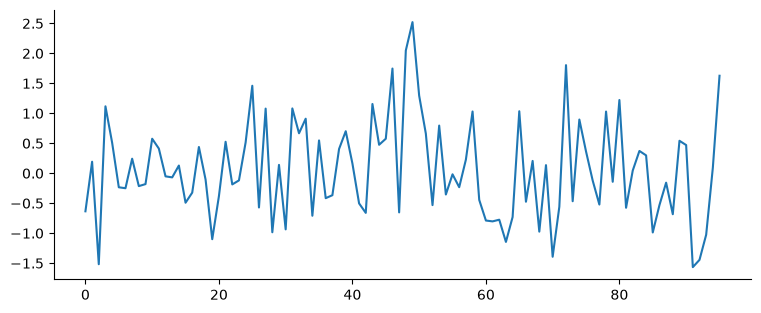

In [29]:
mon_signal = 0*trend + 0*seasonal + noise
plt.plot(mon_signal)

### Support des slides · ACT-06 — Lissage centré et disponibilité

**À t : non.** La mesure x[t+1] n’est pas encore reçue.

**Après réception de x[t+1] : oui**, pour analyser rétrospectivement ou afficher une estimation avec un délai annoncé d’un pas.

Pour agir immédiatement à t, utiliser une moyenne terminant à t.


### Support des slides · ACT-07 — Pic, événement et défaut de mesure

**Deux explications possibles :**

- un événement réel bref, par exemple un chauffage ponctuel ;
- un défaut de mesure ou de transmission.

**Pour les départager :** autre capteur, journal des événements ou état du matériel.

Le retour au niveau habituel distingue ici le pic d’une rupture persistante. **Au premier point élevé, ce retour est encore inconnu.**


### 2.2 TP-02 — Composantes, lissage et données manquantes

Relisez les ressources et exécutez les cellules fournies.  
**EX-04 · 5 min.**  
**EX-05 · 9 min.**  
**EX-06 · 6 min.**  
Terminez avec les rappels d’ACT-08 : ils résument les limites du lissage et du report.


### EX-04 — Expérimenter les composantes d’un signal

**Objectif :** distinguer l’effet d’un paramètre et les composantes d’une série. **Temps :** 5 min. **Travail :** binôme. **Difficulté :** 1.

**Code fourni.** Modifiez un seul paramètre à la fois : comparez amplitude = 0 et 2, puis sigma = 0 et 0,8, en gardant la même pente et la même graine. Réexécutez le calcul et le graphique après chaque changement.

**À expliquer :** ce qui disparaît, ce qui reste, et pourquoi une courbe moins irrégulière n’est pas nécessairement plus facile à prévoir. Terminez avec amplitude = 2 et sigma = 0,8.

**Aides :** commencez par mettre l’amplitude à zéro ; comparez les mêmes instants ; la tendance reste présente lorsque seul le sinus est retiré.

**Erreurs fréquentes :** changer plusieurs paramètres simultanément ; confondre amplitude et période ; appeler « bruit » toute variation irrégulière réelle.

**Réussite :** deux comparaisons à un seul paramètre et une interprétation pour chacune.

In [ ]:
amplitude, slope, sigma = 2., 0.025, 0.8
trend = 18 + slope * t
seasonal = amplitude * np.sin(2 * np.pi * t / 24)
noise = sigma * np.random.default_rng(SEED).normal(0, 1, len(t))
# Code fourni : modifiez les paramètres ci-dessus, un à la fois.
x_simule = trend + seasonal + noise


In [ ]:
if x_simule is None:
    print('EX-04 : à compléter — non vérifié.')
else:
    assert x_simule.shape == (96,)
    np.testing.assert_allclose(x_simule-trend-seasonal, noise, atol=1e-12)
    plt.plot(t, x_simule); plt.xlabel('Temps (heures)')
    plt.ylabel('Température simulée (°C)'); plt.show()
    print('EX-04 : vérification réussie.')


Que reste-t-il quand amplitude=0 ? Que change sigma=0 ? Peut-on connaître exactement le bruit d’une vraie série ?

Votre réponse : …


### EX-05 — Lisser sans connaître le futur

**Objectif :** Implémenter une moyenne mobile causale et identifier son compromis bruit/retard.  
**Durée :** 9 min · **Difficulté :** 2 — application · **Travail :** Binôme  
**Ressources :** x_reference ; fenêtres w=3 et w=13 ; saut de niveau fourni.

**Consigne.** Complétez la tranche utilisée par trailing_mean. Exécutez les tests. Comparez w=3 et w=13 ; expliquez le retard du lissage au voisinage du saut. Les w-1 premières sorties restent NaN.

**Résultat attendu :** Moyenne à t calculée avec les seuls indices t-w+1 à t ; graphique comparatif ; explication du retard.

<details><summary>Aide 1</summary>

À t, quelles observations sont déjà arrivées ?

</details>
<details><summary>Aide 2</summary>

Le dernier indice inclus doit être t.

</details>
<details><summary>Aide 3</summary>

np.mean(values[t-w+1:t+1]) calcule une fenêtre complète se terminant à t.

</details>

**Erreurs fréquentes :** Fenêtre centrée ; moyenne cumulative à la place d’une fenêtre fixe ; remplissage des bords avec zéro ; confondre lissage et prévision.

**Réussite :** Test sur tableau court et test d’invariance au futur réussis ; compromis expliqué.


In [ ]:
def trailing_mean(values, w):
    values = np.asarray(values, dtype=float)
    if not isinstance(w, (int, np.integer)) or w < 1 or w > len(values):
        raise ValueError('w doit être un entier entre 1 et N.')
    out = np.full(len(values), np.nan)
    for t in range(w-1, len(values)):
        # À compléter : remplacez None par la moyenne de la bonne tranche.
        local_mean = None
        if local_mean is None:
            return None
        out[t] = local_mean
    return out

smooth3 = trailing_mean(x_reference, 3)
smooth13 = trailing_mean(x_reference, 13)


In [ ]:
if smooth3 is None or smooth13 is None:
    print('EX-05 : à compléter — non vérifié.')
else:
    z = trailing_mean([1,2,3,4,5], 3)
    assert np.isnan(z[:2]).all()
    np.testing.assert_allclose(z[2:], [2,3,4])
    # Modifier le futur ne doit pas changer les sorties déjà calculées.
    changed = x_reference.copy(); changed[60:] += 1000
    np.testing.assert_allclose(trailing_mean(changed,3)[:60], smooth3[:60], equal_nan=True)
    plt.plot(t,x_reference, alpha=.4, label='Signal')
    plt.plot(t,smooth3,label='Causal w=3'); plt.plot(t,smooth13,label='Causal w=13')
    plt.xlabel('Temps (heures)'); plt.ylabel('Température simulée (°C)')
    plt.legend(); plt.show()
    print('EX-05 : tests numérique et causal réussis.')


In [ ]:
# Démonstration fournie : le calcul centré est rétrospectif.
step_signal = np.r_[np.zeros(25), np.ones(25)*4]
centered = np.full(50, np.nan)
for k in range(2, 48):
    centered[k] = np.mean(step_signal[k-2:k+3])
if smooth3 is not None:
    causal = trailing_mean(step_signal, 5)
    plt.plot(step_signal,label='Saut réel à t=25')
    plt.plot(causal,label='Causal w=5'); plt.plot(centered,'--',label='Centré w=5')
    plt.xlim(18,32); plt.xlabel('Temps (pas)'); plt.ylabel('Signal (u.a.)')
    plt.legend(); plt.show()
else:
    print('Complétez EX-05 pour afficher la comparaison.')


À quelle date le lissage centré commence-t-il à monter ? Pourquoi ? Le lissage causal « prédit-il » le saut ?

Votre réponse : …


### EX-06 — Traiter une absence sans effacer un événement

**Objectif :** Appliquer un report causal limité et discuter un pic isolé.  
**Durée :** 6 min · **Difficulté :** 2 — application · **Travail :** Binôme  
**Ressources :** Copie de x_reference : NaN aux indices 30:33 ; pic artificiel +8 à l’indice 65.

**Consigne.** Complétez forward_fill en conservant la dernière valeur observée. Vérifiez le comportement quand la série commence par NaN. Sur le graphique, distinguez le trou, le pic et un changement durable. Proposez une règle de prudence pour les trous longs.

**Résultat attendu :** Série complétée uniquement après une valeur connue ; indicateur de manque conservé ; commentaire sur le pic.

<details><summary>Aide 1</summary>

Quelle valeur garder en mémoire quand une observation arrive ?

</details>
<details><summary>Aide 2</summary>

Un NaN initial ne peut pas être remplacé par une observation passée inexistante.

</details>
<details><summary>Aide 3</summary>

Dans le cas observé : last = value. Dans le cas manquant : out[i] = last.

</details>

**Erreurs fréquentes :** Interpolation entre passé et futur pour une tâche en ligne ; remplacement initial par la moyenne complète ; suppression automatique des pics.

**Réussite :** Tests incluant un NaN initial réussis ; masque manquant conservé ; politique pour trous longs discutée.


In [ ]:
x_defects = x_reference.copy()
x_defects[30:33] = np.nan
x_defects[65] += 8
missing_mask = np.isnan(x_defects)
plt.plot(t,x_defects); plt.xlabel('Temps (heures)')
plt.ylabel('Température simulée (°C)'); plt.show()
print('Indices manquants :', np.flatnonzero(missing_mask))


In [ ]:
def forward_fill(values):
    out = np.asarray(values, dtype=float).copy()
    last = np.nan
    for i, value in enumerate(out):
        if np.isnan(value):
            # À compléter : reporter la dernière valeur connue.
            replacement = None
            if replacement is None:
                return None
            out[i] = replacement
        else:
            # À compléter : mémoriser l'observation présente.
            last = None
    return out

x_filled = forward_fill(x_defects)


In [ ]:
if x_filled is None:
    print('EX-06 : à compléter — non vérifié.')
else:
    trial = forward_fill([np.nan,2,np.nan,np.nan,5])
    assert np.isnan(trial[0])
    np.testing.assert_allclose(trial[1:], [2,2,2,5])
    np.testing.assert_allclose(x_filled[30:33], np.repeat(x_reference[29],3))
    np.testing.assert_allclose(x_filled[~missing_mask], x_defects[~missing_mask])
    assert missing_mask.sum() == 3
    changed = x_defects.copy(); changed[60:] = 1000
    np.testing.assert_allclose(forward_fill(changed)[:60], x_filled[:60], equal_nan=True)
    plt.plot(t,x_defects,label='Avec défauts')
    plt.scatter(t[missing_mask], x_filled[missing_mask], color='darkorange',label='Report causal')
    plt.xlabel('Temps (heures)'); plt.ylabel('Température simulée (°C)')
    plt.legend(); plt.show()
    print('EX-06 : vérification réussie ; le masque initial est conservé.')


L’absence d’erreur Python prouve-t-elle que le report représente la vraie température ? Quelle information perdrait-on en supprimant missing_mask ? Pourquoi ne pas supprimer tous les pics ?

Votre réponse : …


### Support des slides · ACT-08 — Limites du lissage et du report

1. **Faux :** une grande fenêtre causale réagit généralement plus lentement à un saut.
2. **Faux :** au début, aucune valeur passée n’existe à reporter ; garder l’absence ou choisir une autre règle explicite.
3. **Faux :** un pic peut être un événement réel ; vérifier sa cause avant de supprimer.


## 3. M03 — Autocorrélation et stationnarité · TP-03

**Objectifs :** Calculer une ACF, appliquer une différence et distinguer stationnarité et bruit blanc

**Prérequis :** moyenne, variance, indices. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 4 min). Ces exercices se font dans un temps de pratique séparé. Les rappels « Support des slides » sont fournis, sans exercice supplémentaire.

### Support des slides · M03 — Trois règles de génération

**Corrélation** : lien linéaire entre deux valeurs. **Autocorrélation** : lien entre deux valeurs de la même série séparées d’un **retard**, exprimé en pas.

- **Bruit blanc** : moyenne et dispersion constantes, sans corrélation entre instants distincts. Exemple simplifié : erreurs de mesure indépendantes autour d’une température constante. Une loi normale n’est pas obligatoire pour être blanc.
- **AR(1)**, autorégressif d’ordre 1 : $x_t=a\,x_{t-1}+b+\varepsilon_t$. **t** est l’indice du pas ; **xₜ** et **xₜ₋₁** sont les valeurs actuelle et précédente ; **a** multiplie la valeur précédente ; **b** est une constante ajoutée ; **εₜ** est un nouveau bruit de moyenne zéro, indépendant du passé dans nos simulations. Exemple simplifié : le robot cherche à rejoindre la ligne. On suppose que sa commande corrige 30 % de l’écart à chaque pas ; ce nombre est choisi pour illustrer une correction progressive, pas une propriété générale des robots. Sans nouvelles perturbations, les corrections répétées rapprochent l’écart de zéro. Pour cet écart signé en cm, a=0,7 et b=0. À partir de 2 cm, l’écart attendu est 1,4 cm ; avec une perturbation de +0,2 cm, l’écart observé est 1,6 cm. Sans nouvelles perturbations, l’effet du départ s’atténue : 2 → 1,4 → 0,98 → 0,686 cm. Le bruit peut toutefois faire augmenter une mesure. b n’est pas la moyenne de la série.
- **Marche aléatoire** : x[t]=x[t−1]+ε[t]. Les déplacements ε[t] s’accumulent dans la position x[t]. Exemple : départ 0, déplacements +1,−2,+0,5 ; positions 0,1,−1,−0,5. Un retour au départ est possible par hasard, sans force de rappel.

Dans la cellule suivante, **t** est un indice. Les trois séries sont abstraites, en unités arbitraires : les perturbations sont indépendantes ; l’AR utilise **a=0,7 et b=0** ; la marche cumule les déplacements. L’AR suit la règle de conservation de l’écart du robot. Ce ne sont pas les températures de M02, qui contiennent une tendance et un cycle quotidien.

Un **processus** est la règle aléatoire ; une **réalisation** est la courbe obtenue avec un tirage. **Stationnarité faible** (détaillée ensuite) : moyenne, dispersion et relations à un même retard stables dans le temps.


In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
rng3=np.random.default_rng(2030)
eps3=rng3.normal(size=240)
ar3=np.zeros(240)
for i in range(1,240): ar3[i]=.7*ar3[i-1]+eps3[i]
rw3=np.cumsum(eps3)
fig,axes=plt.subplots(3,1,figsize=(9,5),sharex=True)
for ax,z,label in zip(axes,[eps3,ar3,rw3],['Bruit','AR(1)','Marche aléatoire']):
    ax.plot(z);ax.set_ylabel(label)
axes[-1].set_xlabel('Indice');plt.show()

### Support des slides · ACT-09 — Mémoire de trois processus

**Sur les réalisations affichées :** bruit blanc < AR(1) < marche aléatoire.

Sur les réalisations affichées, ACF empirique au retard 1 :

| Processus | r₁ |
|---|---:|
| Bruit blanc | −0,003 |
| AR(1), a = 0,7, b = 0 | 0,735 |
| Marche aléatoire | 0,984 |

L’AR garde une mémoire ; la marche accumule les innovations. Son ACF empirique élevée ne décrit pas un processus stationnaire.

**r₁** est l’autocorrélation estimée entre deux valeurs successives. La règle de calcul est détaillée plus bas ; ce classement ne constitue pas une preuve générale.


### Support des slides · Aparté — Bruits blanc, rose et marron

Ces couleurs décrivent la répartition des variations entre fréquences. Une **fréquence** est un nombre d’oscillations par unité de temps ; une basse fréquence correspond à une variation lente. La **densité spectrale S(f)** répartit la puissance du signal par fréquence f.

Sur une bande étudiée, les formes idéales sont : blanc, S(f) constante ; rose, proportionnelle à 1/f ; marron, proportionnelle à 1/f². Les couleurs ne désignent pas la distribution des valeurs et n’imposent pas une loi normale.

Le graphique ci-dessous est fourni : blanc indépendant, rose synthétisé sur une bande finie, marron obtenu par cumul. Les courbes sont centrées et mises à la même échelle pour comparer leurs allures ; cela ne prouve pas leur stationnarité. On peut penser à des sons synthétiques : souffle fin, souffle plus grave, grondement sourd. Les sons naturels ne sont pas automatiquement des bruits de couleur idéale.

[Source : J. O. Smith, Spectral Audio Signal Processing](https://www.dsprelated.com/freebooks/sasp/Spectrum_Analysis_Noise.html).


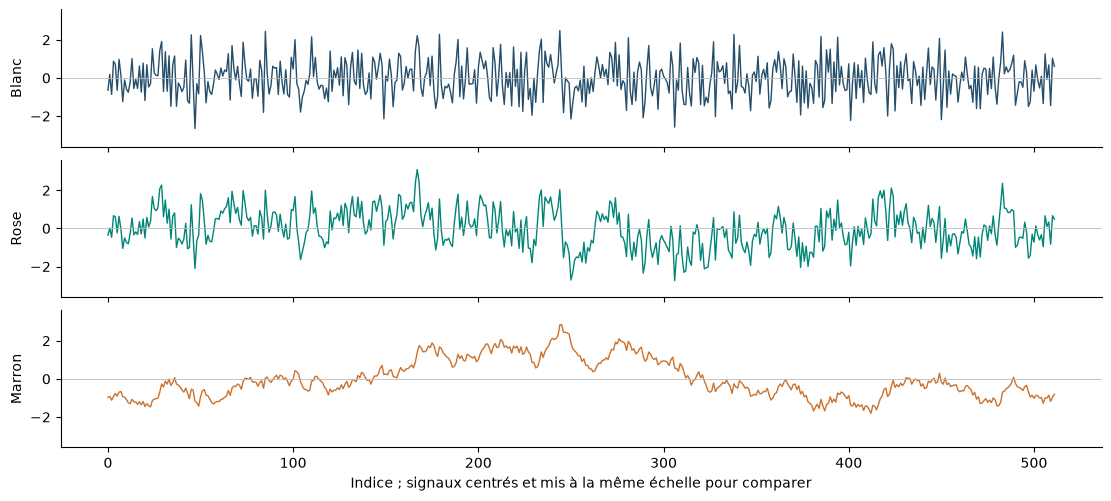

In [25]:
# Fourni : exemples simulés, sans nouveau code à compléter.
from scripts.generer_figures_m03 import figure_bruits, figure_retards
fig = figure_bruits()
plt.show()


### Support des slides · M03 — Paires, moyenne globale et retard zéro

Retour au **signal de température de M02**, avec 480 observations horaires, tendance, cycle quotidien et bruit. Le nuage au retard 1 compare x[t−1] et x[t] ; au retard 24, x[t−24] et x[t]. t est l’indice actuel et k le retard. Ce ne sont pas les trois processus d’ACT-09. Le point orange utilise la même mesure actuelle x[48], avec x[47] ou x[24] comme mesure passée.

**Moyenne globale** : une seule moyenne pour toutes les observations du segment étudié. Pour x=[1,2,1,2], elle vaut 1,5 et les écarts sont [−0,5,+0,5,−0,5,+0,5]. Au retard 1, on conserve ce même niveau pour les deux tranches ; on ne recalcule pas deux moyennes.

$$r_k=\frac{\sum_{t=k}^{N-1}(x_t-\bar x)(x_{t-k}-\bar x)}{\sum_{t=0}^{N-1}(x_t-\bar x)^2}$$

**N** : nombre d’observations ; **t** : indice de 0 à N−1 ; **k** : retard ; **xₜ** : valeur actuelle ; **xₜ₋ₖ** : valeur k pas plus tôt ; **x̄** : moyenne globale ; **Σ** : addition des termes ; **rₖ** : autocorrélation estimée au retard k. Le numérateur utilise N−k paires ; le dénominateur garde la même somme des carrés des N écarts.

À **k=0**, chaque valeur est comparée à elle-même : les deux sommes sont identiques et r₀=1 si la série varie. Sur [1,2,1,2], c’est 1/1. Sur [5,5,5,5], tous les écarts sont nuls : la variance est nulle et 0/0 est indéfini. Le résultat 1 au retard zéro ne montre aucune prévisibilité.

Le squelette d’EX-07 suppose une série non constante. Facultatif : ajouter un contrôle du dénominateur pour refuser une série constante, comme la fonction acf_simple fournie.


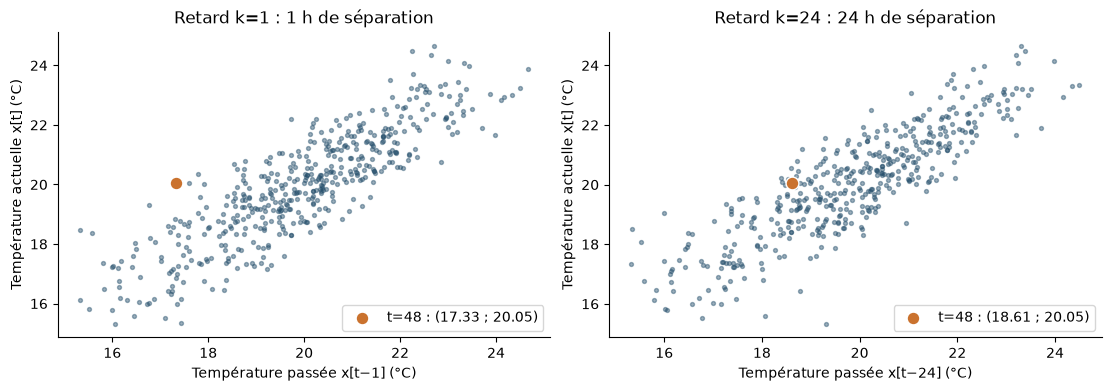

In [26]:
# Fourni : les températures de M02 et leurs paires au retard1 ou24.
fig = figure_retards()
plt.show()


### Support des slides · ACT-10 — Corrélation et tendance commune

**Non : une tendance commune peut créer une forte corrélation des niveaux.**

Examiner les variations ou retirer la tendance, puis comparer les résidus.

Contrôler aussi les facteurs communs possibles. Une corrélation persistante ne suffit toujours pas à établir une causalité.


### Support des slides · ACT-11 — Diagnostiquer après différenciation

**Premier candidat :** différence saisonnière x[t] − x[t−24].

Le sinus quotidien du générateur disparaît ; une tendance linéaire laisse un décalage constant.

Examiner ensuite la courbe, la moyenne, la dispersion et l’ACF. Ajouter une différence seulement si le diagnostic le justifie : elle peut créer des dépendances artificielles.


### EX-07 — Calculer une ACF

**Objectif :** Implémenter la convention globale de l’ACF.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le numérateur de la fonction, puis tracez les ACF du bruit et de l’AR. Expliquez le signe à k=1 pour [1,2,1,2].

**Résultat attendu :** Deux courbes et une justification de r1=−0,75.

<details><summary>Aide 1</summary>Centrez avec une seule moyenne calculée sur toutes les observations de values.</details>

<details><summary>Aide 2</summary>Comparez z[k:] et z[:-k].</details>

<details><summary>Aide 3</summary>Le produit scalaire est z[k:] @ z[:len(z)-k].</details>

**Erreurs fréquentes :** Recentrer chaque tranche ; oublier le dénominateur commun.

**Réussite :** Cas papier exact et invariance à une translation réussis.

In [ ]:
def acf_a_completer(values,maxlag=12):
    z=np.asarray(values,float)-np.mean(values)
    out=[1.]
    for k in range(1,maxlag+1):
        numerator=None  # À compléter
        if numerator is None: return None
        out.append(numerator/(z@z))
    return np.asarray(out)
acf_result=acf_a_completer(ar3)

In [ ]:
if acf_result is None: print('EX-07 : à compléter — non vérifié.')
else:
    np.testing.assert_allclose(acf_a_completer([1,2,1,2],1),[1,-.75])
    np.testing.assert_allclose(acf_result,acf_a_completer(ar3+100))
    assert np.all(np.abs(acf_result)<=1+1e-12)
    print('EX-07 : vérification réussie.')
    for zz,label in [(eps3,'Bruit'),(ar3,'AR')]:plt.plot(acf_a_completer(zz),label=label)
    plt.xlabel('Retard');plt.ylabel('ACF');plt.legend();plt.show()

Une translation du niveau change-t-elle l’ACF ? Pourquoi ?

Votre interprétation : …

### EX-08 — Différencier et reconstruire

**Objectif :** Relier transformation, longueur et unité.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez la différence saisonnière, reconstruisez le signal à partir des différences au pas 1, puis comparez les ACF.

**Résultat attendu :** N−24 différences saisonnières ; reconstruction exacte des observations, puis interprétation.

<details><summary>Aide 1</summary>À quelle observation faut-il comparer x[t] ?</details>

<details><summary>Aide 2</summary>Alignez x[24:] et x[:-24].</details>

<details><summary>Aide 3</summary>La reconstruction commence par x[0], puis utilise une somme cumulée.</details>

**Erreurs fréquentes :** Oublier le niveau initial ; présenter une reconstruction comme une prévision.

**Réussite :** Longueurs correctes et reconstruction égale au signal.

In [ ]:
d1=np.diff(x_long)
d24=None  # À compléter
recon=None  # À compléter

In [ ]:
if d24 is None or recon is None: print('EX-08 : à compléter — non vérifié.')
else:
    assert len(d24)==len(x_long)-24
    np.testing.assert_allclose(d24,x_long[24:]-x_long[:-24])
    np.testing.assert_allclose(recon,x_long)
    print('EX-08 : vérification réussie.')
    for zz,label in [(x_long,'Brute'),(d1,'Différence 1'),(d24,'Différence 24')]:plt.plot(acf_simple(zz,36),label=label)
    plt.xlabel('Retard');plt.ylabel('ACF');plt.legend();plt.show()

Quels effets restent après différence saisonnière ? Pourquoi la reconstruction exacte n’est-elle pas une réussite prédictive ?

Votre interprétation : …

### EX-09 — Diagnostiquer des propriétés

**Objectif :** Distinguer dépendance, stationnarité et hypothèse statistique.
**Temps :** 4 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez les trois décisions ; justifiez en deux phrases. Facultatif : exécutez le test ADF fourni sur le bruit et la marche aléatoire.

**Résultat attendu :** Trois décisions avec hypothèses explicites.

<details><summary>Aide 1</summary>Un processus peut-il fluctuer autour d’un niveau tout en étant corrélé ?</details>

<details><summary>Aide 2</summary>La stationnarité concerne moyenne, dispersion et dépendance ; le bruit blanc ajoute des autocorrélations nulles aux retards non nuls.</details>

<details><summary>Aide 3</summary>Un non-rejet n’est pas une preuve.</details>

**Erreurs fréquentes :** Déduire indépendance de corrélation nulle ; prendre une p-valeur pour une preuve.

**Réussite :** Décisions correctes et distinction de l’hypothèse nulle expliquée.

In [ ]:
decisions3={'ar_stationnaire_peut_etre_previsible':None,
            'acf_nulle_prouve_independance':None,
            'non_rejet_adf_prouve_racine_unitaire':None}
# Facultatif, fourni : test ADF, hypothèse nulle de racine unitaire.
executer_adf = False  # Facultatif : passez à True pour lancer le test.
if executer_adf and all(v is not None for v in decisions3.values()):
    try:
        from statsmodels.tsa.stattools import adfuller
        for z,label in [(eps3,'Bruit'),(rw3,'Marche aléatoire')]:
            result=adfuller(z,maxlag=4,regression='c',autolag='AIC')
            print(label,'p ADF :',round(result[1],4))
    except ImportError:
        print('Extension ADF : statsmodels nécessaire.')

In [ ]:
if any(v is None for v in decisions3.values()): print('EX-09 : à compléter — non vérifié.')
else:
    assert list(decisions3.values())==[True,False,False]
    print('EX-09 : vérification réussie ; justifiez les hypothèses.')

Quelle différence entre le processus stationnaire théorique et cette courte réalisation ?

Votre interprétation : …

### Support des slides · ACT-12 — Stationnarité et prévisibilité

**Faux.** Un AR(1) stable peut être stationnaire et dépendre de son passé.

Avec des innovations centrées, sa moyenne conditionnelle à un pas vaut **c + φx[t]**.

Des propriétés statistiques stables n’imposent pas l’absence de mémoire.


## 4. M04 — Modéliser la dépendance au passé · TP-06

**Objectifs :** Estimer AR(1), interpréter ARIMA et tester SARIMA (Seasonal AutoRegressive Integrated Moving Average), sa version saisonnière, sur des blocs futurs

**Prérequis :** M03 ; les rôles d’apprentissage, validation et test sont rappelés en M04. Exécutez les imports, puis les ressources ci-dessous.

**En fin de M04 :** exécutez les imports et les ressources, puis faites **EX-17 (7 min)** et **TP-06-S (13 min)** en binôme. EX-16 et EX-18 sont des approfondissements. **TP-06-R** propose ensuite de chercher et tester une série réelle (20–30 min, facultatif).

### Support des slides M04 — valeurs passées et perturbations

#### Diagramme de retard — diapo 79

Chaque point du graphique AR(1) représente **(écart précédent, écart actuel)** du robot. C’est un **diagramme de retard**. En systèmes dynamiques, ces coordonnées sont utilisées pour reconstruire une représentation de l’**espace des phases**, l’ensemble des états possibles. Deux coordonnées ne garantissent pas une reconstruction complète, notamment pour un signal bruité. [Référence : T. Sauer, 2006](https://www.math.kyoto-u.ac.jp/~kokubu/RIMS2006/sauer.pdf).

#### Un autre contexte pour AR(2) — diapo 81

On quitte le robot : **x_t est la charge quotidienne d’un service d’assistance, en heures de travail pour toute l’équipe**. Dans le scénario simulé, x_t = 15 + 0,65 x_(t−1) + 0,20 x_(t−2) + ε_t. La perturbation ε_t est centrée et exprimée en heures. Pour 100 h hier et 110 h avant-hier, la prévision est 102 h. Les coefficients sont des poids, pas des parts devant totaliser 100 %. Cet exemple illustratif est distinct du stock utilisé dans le TP.

#### Valeurs passées et perturbations

**Innovation (ε_t) :** une perturbation nouvelle, imprévisible à partir des observations précédentes. Le mot indique qu’elle apporte une information nouvelle. Dans le MA(1) de la diapo 83, une perturbation précédente de +4 rend 2,4 unités prévisibles au pas suivant ; si la sortie est 3,4, la nouvelle innovation est +1. Les innovations sont supposées centrées et non corrélées ; on les estime par les résidus de prévision à un pas dans le modèle adapté, sans les observer directement. [Modèles MA — FPP3](https://otexts.com/fpp3/MA.html) · [Innovations — statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.tsa.innovations.arma_innovations.arma_innovations.html).

Dans les exemples de réponse, un **choc** est une innovation ponctuelle, positive ou négative. Exemple : une erreur ponctuelle de transmission perturbe une mesure. Ici, x est l’erreur par rapport à une mesure idéale, pas la température absolue ni l’écart d’un robot.

AR(1) transmet un choc par les valeurs suivantes ; MA(1) réutilise directement l’innovation au pas suivant ; ARMA combine les deux mécanismes. Avec un seul choc de +4 et aucun nouveau bruit, MA(1) de coefficient 0,6 produit 4 → 2,4 → 0. ARMA(1,1), coefficients 0,7 et 0,6, produit 4 → 5,2 → 3,64.

![Réaction au même choc simulé.](images/m06_arma_choc.svg)

**MA(q) généralise MA(1)** : l’innovation actuelle plus q innovations passées. Avec m=0, c1=0,6 et c2=0,2, un choc isolé de +4 donne 4 → 2,4 → 0,8 → 0, si aucune nouvelle innovation ne s’ajoute. Les mots « innovation » et « perturbation nouvelle » désignent ici la même composante ; « bruit blanc » décrit les hypothèses de leur suite.

Une moyenne glissante lisse des **observations** ; le modèle MA utilise des **innovations**. Les noms proches ne désignent pas le même calcul.

### Données de TP-06 — du robot à un stock simulé

Le robot servait à montrer un AR(1) directement sur un écart. Ici, on suit **un niveau de stock**, en unités de volume, à chaque pas d’observation. Ses ajouts et retraits successifs donnent des variations qui dépendent de la variation précédente.

- `d6` : variations simulées (positives ou négatives) ; `z6` : niveau obtenu en les cumulant à partir d’un niveau initial.
- `train6` : niveaux aux indices 0–119, seuls utilisés pour ajuster.
- Indices 120–143 : bloc suivant pour comparer ; 144–179 : test réservé.

Dans EX-16, vous ajustez un AR(1) **aux variations calculées avec les niveaux d’apprentissage**. Dans EX-17, ARIMA traite la différenciation et le retour aux niveaux. Les données sont simulées ; le modèle du stock est une hypothèse d’illustration.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
eps6=np.random.default_rng(2027).normal(0,.7,180)
d6=np.empty(180);d6[0]=.1
for i in range(1,180):d6[i]=.1+.55*d6[i-1]+eps6[i]
z6=10+np.cumsum(d6)
# 0–119 : apprentissage ; 120–143 : validation ; 144–179 : test réservé.
train6=z6[:120]
plt.plot(z6[:144]);plt.xlabel('Pas d’observation');plt.ylabel('Niveau de stock simulé (unités)');plt.show()

### Support des slides · ACT-21 — Prévision AR récursive

**Contexte :** le robot cherche à revenir vers la ligne. Son écart est mesuré en cm ; un pas est une étape de correction, pas un jour. Le modèle conserve 70 % de l’écart précédent, sans ajout constant.

Dernier écart mesuré : **2 cm**. **À un pas :** 0,7 × 2 = **1,4 cm**. **À deux pas :** 0,7 × 1,4 = **0,98 cm**.

Pour le second pas, on utilise la première prévision car aucune nouvelle mesure n’est disponible. Les innovations futures ont une moyenne conditionnelle nulle ; les vraies mesures pourront donc différer de ces prévisions.

![Deux prévisions émises depuis la même mesure.](images/m04_robot_deux_pas.svg)

### Support des slides · ACT-22 — Modèle MA et moyenne glissante

**Un choc est ici une innovation ponctuelle (perturbation nouvelle)**, par exemple une erreur ponctuelle dans une mesure transmise. On ne parle pas d’une collision du robot.

Dans l’exemple MA(1), l’erreur en sortie combine l’innovation actuelle et 0,6 fois la précédente. Une seule innovation de +4 unités produit **4 → 2,4 → 0**, sans nouvelles innovations.

Une **moyenne glissante de trois observations** lisse des valeurs mesurées. Un **MA(3)** utilise l’innovation courante et les trois innovations précédentes, avec des coefficients de modèle : ce n’est pas le même calcul. Les innovations d’un modèle ajusté sont estimées à partir de ce que le modèle n’explique pas.

### Support des slides · ACT-23 — Saisonnalité résiduelle

Le modèle peut laisser une **structure saisonnière quotidienne** dans les résidus.

Tester un candidat saisonnier, des retards de période ou des variables calendaires.

Comparer sur validation, à horizon et cibles identiques. Garder le test final pour la méthode retenue.


### EX-16 — Ajuster un AR(1)

**Objectif :** Relier fenêtre, matrice et coefficient autorégressif.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Contexte et étapes :** On change de données par rapport au robot : `z6` est un niveau de stock simulé, construit en cumulant des ajouts et des retraits. `train6` contient uniquement les 120 premières valeurs. `diff16 = np.diff(train6)` représente leurs variations successives.

Chaque ligne de la matrice doit associer **une constante et la variation précédente** à la **variation suivante**, utilisée comme cible. Après ajustement, indiquez comment passer d’une variation prévue à un niveau prévu.

**Consigne :** Ajustez un AR(1) avec intercept aux différences d’apprentissage. Complétez la matrice et le calcul des coefficients.

**Résultat attendu :** Deux coefficients, prévision d’une variation et interprétation.

<details><summary>Aide 1</summary>Les entrées sont d[t−1], cibles d[t].</details>

<details><summary>Aide 2</summary>Ajoutez une colonne de 1.</details>

<details><summary>Aide 3</summary>np.linalg.lstsq(X,y,rcond=None)[0].</details>

**Erreurs fréquentes :** Ajuster sur les niveaux alors que la consigne porte sur les différences ; utiliser la cible en entrée.

**Réussite :** Résidu orthogonal aux colonnes de X, observation future exclue.

In [ ]:
diff16=np.diff(train6)
X16=None  # À compléter
coef16=None  # À compléter

In [ ]:
if X16 is None or coef16 is None: print('EX-16 : à compléter — non vérifié.')
else:
    assert X16.shape==(118,2)
    np.testing.assert_array_equal(X16[:,1],diff16[:-1])
    residual=diff16[1:]-X16@coef16
    np.testing.assert_allclose(X16.T@residual,0,atol=1e-8)
    print('EX-16 : vérification réussie.')

Quelle quantité faut-il ajouter au niveau pour produire une prévision de z6 ?

Votre interprétation : …

### Support des slides M04 — comparaison AIC et validation (EX-17)

**AIC — Akaike Information Criterion**, critère d’information d’Akaike : il combine l’ajustement probabiliste et une pénalité pour le nombre de paramètres. On compare ici les mêmes données et la même différenciation.

![Les scores calculés avec les données et les trois candidats d’EX-17.](images/m04_aic_validation.svg)

AIC et MAE de validation peuvent classer différemment les modèles. Pour reproduire cette comparaison, utilisez EX-17 ; l’exemple du robot précédent illustre seulement la récursion à deux pas. Les résultats dépendent de cette simulation et de ce bloc futur.

### EX-17 — Comparer trois ARIMA

**Objectif :** Ajuster des ordres documentés sans grille coûteuse.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez les trois ordres candidats puis exécutez le code fourni. Comparez MAE validation, AIC et statut de convergence.

**Protocole :** Les trois modèles voient uniquement `z6[0:120]`. Chacun émet, à l’indice 119, un bloc de **24 prévisions en niveaux** ; on les compare ensuite à `z6[120:144]`, sans ajouter de mesure intermédiaire. Les trois modèles autorisent la même dérive (`trend="t"`). L’AIC décrit leur compromis sur l’apprentissage ; la MAE décrit leurs erreurs sur le bloc suivant.

**Résultat attendu :** Trois lignes de résultats, choix argumenté pour le bloc 120–143.

<details><summary>Aide 1</summary>Même d=1 pour les trois candidats.</details>

<details><summary>Aide 2</summary>Commencez par (0,1,0), puis ajoutez p ou q.</details>

<details><summary>Aide 3</summary>Les candidats sont (0,1,0), (1,1,0), (1,1,1).</details>

**Erreurs fréquentes :** Lire d comme une saison ; comparer des AIC de données différentes ; masquer les avertissements.

**Réussite :** Trois candidats, mêmes données, prévisions en niveaux, convergence vérifiée.

In [ ]:
orders17=None  # À compléter : liste de trois tuples
results17=None
if orders17 is not None and ARIMA is not None:
    results17=[]
    for order in orders17:
        fit=ARIMA(train6,order=order,trend='t').fit()
        pred=np.asarray(fit.forecast(24))
        results17.append((order,mae(z6[120:144],pred),fit.aic,fit.mle_retvals.get('converged',True)))
    print(results17)

In [ ]:
if results17 is None: print('EX-17 : à compléter — non vérifié.')
else:
    assert orders17==[(0,1,0),(1,1,0),(1,1,1)]
    assert len(results17)==3 and all(np.isfinite(r[1]) for r in results17)
    assert all(r[3] for r in results17), 'Convergence à examiner avant comparaison.'
    print('EX-17 : vérification réussie.')

Le modèle dont l’AIC est le plus faible est-il forcément le meilleur pour ce bloc ?

Votre interprétation : …

### EX-18 — Interpréter un ajustement et ses résidus

**Objectif :** Relier sortie API, innovation et diagnostic.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Décidez si forecast retourne des niveaux et si une ACF résiduelle nulle prouve l’indépendance. Exécutez le diagnostic fourni après avoir complété les décisions.

**Résultat attendu :** Deux décisions et lecture graphique des résidus.

<details><summary>Aide 1</summary>L’API reçoit les niveaux z6.</details>

<details><summary>Aide 2</summary>Une corrélation nulle est une propriété de second ordre.</details>

<details><summary>Aide 3</summary>forecast restitue les niveaux ; l’indépendance ne suit pas de l’ACF.</details>

**Erreurs fréquentes :** Cumuler deux fois les niveaux ; prendre un résidu pour une innovation vraie.

**Réussite :** Interprétation de l’API et limites du diagnostic expliquées.

In [ ]:
decisions18={'forecast_en_niveaux':None,'acf_nulle_prouve_independance':None}
if ARIMA is not None and all(v is not None for v in decisions18.values()):
    diagnostic18=ARIMA(train6,order=(1,1,0),trend='t').fit()
    resid18=np.asarray(diagnostic18.resid)[2:]
    plt.plot(acf_simple(resid18,12));plt.xlabel('Retard');plt.ylabel('ACF résidus');plt.show()

In [ ]:
if any(v is None for v in decisions18.values()): print('EX-18 : à compléter — non vérifié.')
else:
    assert list(decisions18.values())==[True,False]
    if ARIMA is not None:
        assert len(diagnostic18.forecast(6))==6
    print('EX-18 : vérification réussie ; expliquez les limites des résidus.')

Quelle nouvelle expérience proposer si un motif saisonnier persiste ?

Votre interprétation : …

### Support des slides · ACT-24 — Unité des prévisions ARIMA

**Non, si les niveaux de la série ont été fournis à l’API ARIMA.**

`forecast` restitue alors des **niveaux**, dans l’unité d’origine, même avec d = 1.

Les cumuler ferait une seconde reconstruction incorrecte. Cumuler seulement des variations prévues par un modèle ajusté explicitement sur ces variations.


### TP-06-S — Tester un SARIMA sur un motif hebdomadaire

**Objectif :** tester l’apport d’une mémoire saisonnière, avec des prévisions comparables.
**Temps :** 13 min · **Difficulté :** 2 · **Travail :** binôme.
**Repère :** slides 96–97 ; `statsmodels` requis, CPU, aucun téléchargement.

**Nouvelles données :** charge quotidienne d’un service d’assistance, en heures pour l’équipe. Cette simulation contient explicitement un motif de **7 jours**. Elle est distincte du stock non saisonnier d’EX-17 et de la simulation AR(2) des slides.

**Protocole :** indices 0–111 pour ajuster ; 112–139 pour comparer 28 prévisions émises depuis 111, sans nouvelle mesure ; 140–167 pour tester le choix fixé, après réajustement sur 0–139. Les ordres candidats sont fixés avant de voir les blocs futurs. Le programme affiche le test seulement après avoir fixé le choix sur validation : ne le modifiez plus ensuite.

**Consigne :**
1. Exécutez les données fournies et repérez le motif de 7 jours.
2. Complétez `seasonal_order_s6` pour tester **SARIMA(1,0,0)×(0,1,1)₇**.
3. Exécutez la comparaison fournie avec ARIMA(1,1,0), naïf et saisonnier. Lisez les courbes, les MAE (erreurs absolues moyennes, en heures) et la convergence.
4. Expliquez ce que SARIMA apporte ici et comparez sa validation au résultat sur le test.

**Notation :** `order=(p,d,q)` décrit valeurs passées, différences et innovations passées ; `seasonal_order=(P,D,Q,m)` décrit ces mêmes rôles aux retards de période m. Ici : P=0, D=1 (différence à 7 jours), Q=1 (innovation de la semaine précédente), m=7. `trend="t"` autorise une dérive pour les deux modèles ; une seule différence est appliquée, au pas 1 ou au pas 7.

**Résultat attendu :** quatre courbes de prévision sur les mêmes dates, quatre MAE de validation, convergence vérifiée, puis un test du choix retenu.

<details><summary>Aide 1 — démarrer</summary>Combien de jours contient le motif répété ? Ce nombre est m, pas P.</details>
<details><summary>Aide 2 — méthode</summary>Traduisez dans l’ordre les quatre paramètres saisonniers P, D, Q, m.</details>
<details><summary>Aide 3 — solution partielle</summary>Le tuple commence par (0, 1, 1, …). Le dernier nombre est le nombre de mesures par semaine.</details>

**Erreurs fréquentes :** choisir m=24 malgré le pas quotidien ; comparer des horizons différents ; ajuster sur tout le signal ; préférer un modèle non convergé ; modifier les ordres après avoir vu le test.
**Réussite :** période justifiée, mêmes cibles, comparaison à une référence et conclusion limitée à cette expérience.

In [ ]:
# Données et outils fournis : indépendants d’EX-16 à EX-18.
from scripts.tp_sarima import comparer_sarima, tracer_comparaison
t_s6 = np.arange(168)
z_s6 = (20 + .025*t_s6 + 4*np.cos(2*np.pi*t_s6/7)
        + np.random.default_rng(4206).normal(0, .6, len(t_s6)))
train_s6 = z_s6[:112]
plt.plot(t_s6[:140], z_s6[:140])
plt.axvline(111.5, color='gray', linestyle=':')
plt.xlabel('Jour'); plt.ylabel('Charge simulée (heures de travail)')
plt.title('112 jours pour ajuster ; 28 jours pour comparer ; test encore réservé')
plt.show()


In [ ]:
seasonal_order_s6 = None  # À compléter : (P, D, Q, m)
resultats_s6 = None
if ARIMA is not None and seasonal_order_s6 is not None:
    resultats_s6 = comparer_sarima(z_s6, n_train=112, horizon=28,
                                 periode=7, seasonal_order=seasonal_order_s6)


In [ ]:
if ARIMA is None:
    print('TP-06-S : statsmodels nécessaire ; travaillez sur un poste équipé.')
elif resultats_s6 is None:
    print('TP-06-S : à compléter — non vérifié.')
else:
    assert seasonal_order_s6 == (0, 1, 1, 7)
    assert resultats_s6['origine_validation'] == 111
    assert resultats_s6['origine_test'] == 139
    assert all(fit.nobs == 112 for fit in resultats_s6['modeles'].values())
    assert all(len(p) == 28 and np.isfinite(p).all()
               for p in resultats_s6['previsions_validation'].values())
    assert resultats_s6['tableau_validation']['Convergence'].all(), 'Examinez la convergence.'
    print(resultats_s6['tableau_validation'].to_string(index=False))
    print('Choix fixé sur validation :', resultats_s6['choix'])
    print('MAE test du choix fixé :', round(resultats_s6['mae_test'], 3), 'heures')
    tracer_comparaison(z_s6, resultats_s6, unite='Charge simulée (heures)', pas='Jour')
    print('TP-06-S : vérification réussie.')


**Interprétation :** pourquoi l’ARIMA non saisonnier manque-t-il le motif ? SARIMA bat-il aussi la règle saisonnière ? Que montrent les résidus au décalage de 7 jours ? Pourquoi la MAE de test peut-elle différer de celle de validation ? Cette expérience prouve-t-elle que SARIMA est toujours préférable ?

Votre réponse : …

**Facultatif, après le premier bilan :** essayez Q=0 ou une autre période justifiée sur le seul apprentissage ; utilisez un nouveau bloc de validation pour cette nouvelle sélection. Ne réutilisez pas les chiffres de test déjà consultés comme critère de choix.

### TP-06-R — Chercher et tester une série réelle

**Objectif :** transférer la comparaison à un jeu de données documenté.
**Temps :** 20–30 min, prolongement facultatif · **Difficulté :** 2–3 · **Travail :** binôme.
**Repère :** fin de M04, slide 97. Le code fourni ci-dessous fonctionne avec un exemple réel local.

**Consigne :** cherchez une série qui vous intéresse (météo, fréquentation, consommation électrique…). [data.gouv.fr](https://www.data.gouv.fr/) est une piste. Notez sa source, les conditions de réutilisation, la variable et son unité. Repérez le pas de temps et proposez une période saisonnière et un horizon. Comparez au moins un modèle à une référence sur les mêmes dates, sans utiliser le test pour choisir.

Pour démarrer, `data/co2_mensuel.csv` contient **144 moyennes mensuelles de CO₂ à Mauna Loa, 1987–1998**, en **ppmv — parties par million en volume**. Elles sont calculées depuis les mesures hebdomadaires livrées avec statsmodels ; ce ne sont pas les moyennes mensuelles officielles NOAA/Scripps. Aucun mois n’est interpolé. La série présente une tendance et un motif annuel ; le candidat saisonnier utilise m=12. [Provenance et domaine public](https://www.statsmodels.org/stable/datasets/generated/co2.html) ; traitement détaillé dans `data/SOURCES.md`.

**CSV — Comma-Separated Values :** fichier tabulaire à valeurs séparées par des virgules. Pour votre jeu, préparez deux colonnes `date` (format YYYY-MM-DD) et `valeur`. Déposez le fichier dans `data/` et adaptez les paramètres indiqués. Pour ce TP court : m entre 2 et 24, au moins dix cycles pour ajuster et deux blocs futurs. Le code conserve un petit extrait final pour limiter les calculs.

**Résultat attendu :** une source et un protocole documentés, une courbe, des prévisions comparables, MAE de validation et de test, une conclusion avec une limite.

<details><summary>Aide 1 — démarrer</summary>Une observation représente-t-elle une heure, un jour ou un mois ? Combien d’observations contient un cycle ?</details>
<details><summary>Aide 2 — méthode</summary>Commencez avec l’exemple CO₂, puis remplacez le fichier. Vérifiez les dates, doublons et trous avant l’ajustement.</details>
<details><summary>Aide 3 — solution partielle</summary>Pour des moyennes mensuelles avec un motif annuel : fréquence MS (début de mois), période 12, horizon 12 mois.</details>

**Erreurs fréquentes :** choisir une période sans contexte ; supprimer les dates manquantes et changer le pas ; remplir un trou à partir du futur ; confondre données simulées et réelles ; omettre la source.
**Réussite :** paramètres justifiés, dates régulières ou traitement expliqué, même protocole pour tous les candidats, conclusion sans sélection sur le test.

In [ ]:
# Code fourni. Modifiez ces paramètres pour le fichier que vous avez choisi.
import pandas as pd
fichier_reel = 'data/co2_mensuel.csv'
separateur_reel = ','
frequence_reelle = 'MS'  # MS = début de mois ; D = jour ; h = heure.
m_reel = 12
horizon_reel = 12
resultats_reels = None
if ARIMA is None:
    print('TP-06-R : statsmodels nécessaire ; le fichier réel reste disponible dans data/.')
else:
    df_reel = pd.read_csv(fichier_reel, sep=separateur_reel)
    dates_reelles = pd.to_datetime(df_reel['date'], errors='raise')
    serie_reelle = pd.Series(pd.to_numeric(df_reel['valeur'], errors='raise').to_numpy(),
                             index=dates_reelles).sort_index()
    assert not serie_reelle.index.has_duplicates, 'Dates répétées : justifiez une agrégation.'
    serie_reelle = serie_reelle.asfreq(frequence_reelle)
    assert serie_reelle.notna().all(), 'Trous : définir un traitement causal avant de poursuivre.'
    assert np.isfinite(serie_reelle.to_numpy()).all()
    assert 2 <= m_reel <= 24 and 1 <= horizon_reel <= 48, 'Limites du TP CPU.'
    n_apprentissage_reel = 10*m_reel
    n_total_reel = n_apprentissage_reel + 2*horizon_reel
    assert len(serie_reelle) >= n_total_reel, 'Il faut au moins dix cycles et deux blocs futurs.'
    extrait_reel = serie_reelle.iloc[-n_total_reel:]
    resultats_reels = comparer_sarima(extrait_reel.to_numpy(), n_apprentissage_reel,
                                    horizon_reel, m_reel, (0, 1, 1, m_reel))
    print('Extrait :', extrait_reel.index[0], 'à', extrait_reel.index[-1])
    print(resultats_reels['tableau_validation'].to_string(index=False))
    print('Choix fixé :', resultats_reels['choix'], '; MAE test :', round(resultats_reels['mae_test'], 3))
    tracer_comparaison(extrait_reel.to_numpy(), resultats_reels,
                       unite='Valeur (unité de votre jeu ; CO₂ : ppmv)', pas='Date',
                       index=extrait_reel.index)
    assert len(resultats_reels['prevision_test']) == horizon_reel
    assert np.isfinite(resultats_reels['prevision_test']).all()
    print('TP-06-R : vérification réussie ; documentez le jeu et le protocole.')


**Votre compte rendu :**

- Jeu choisi, lien de source, conditions de réutilisation et unité : …
- Pas de temps, période m, horizon et dates des trois blocs : …
- Classement sur validation, méthode retenue et résultat sur le test : …
- Lecture des courbes/résidus et une limite de la comparaison : …

Si vous utilisez un autre jeu, expliquez pourquoi ce candidat SARIMA est raisonnable. Une tendance et une saison ne suffisent pas à garantir qu’il conviendra.

## 5. M05 — Quel poids donner au passé ? · TP-05

**Objectifs :** mettre à jour un niveau et choisir alpha sur validation.

**Prérequis :** récursion et validation. Exécutez les imports, puis les ressources ci-dessous.

EX-13 et EX-14 portent sur le niveau simple. Holt-Winters et EX-15 sont dans le complément M08.

### Support des slides M05 — suivre un changement de niveau

Le niveau passe de 10 à 14 dans cette simulation. Une mémoire longue réagit lentement, une mémoire courte suit davantage les fluctuations. Le coefficient alpha règle ce compromis ; il est choisi sur des cibles de validation.

![Deux réactions au même saut de niveau simulé.](images/m05_commencer_par_un_saut.svg)

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
z5=np.r_[np.ones(30)*10,np.ones(30)*14]+np.random.default_rng(5).normal(0,.4,60)
plt.plot(z5);plt.xlabel('Indice');plt.ylabel('Niveau simulé');plt.show()

### Support des slides · ACT-17 — Réactivité et bruit

**Mémoire courte :** adaptation rapide au saut, mais sensibilité au bruit et aux mesures erronées.

**Mémoire longue :** fluctuations atténuées, mais adaptation plus lente au nouveau niveau.

Choisir le compromis selon la tâche et le coût des erreurs ; examiner plusieurs observations et le contexte.


### Support des slides · ACT-18 — Erreur de filtrage et erreur de prévision

**Non : level[t] utilise déjà x[t].**

La prévision émise avant de recevoir x[t] utilise le niveau précédent :

```python
forecast[t] = level[t-1]
error[t] = x[t] - forecast[t]
```

À α = 1, l’erreur de filtrage est nulle ; l’erreur de prévision peut rester élevée.


### EX-13 — Implémenter un niveau SES

**Objectif :** Respecter l’ordre observation, mise à jour et prévision.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez la mise à jour. Comparez alpha=0,15 et 0,8 sur le saut ; distinguez niveau courant et prévision à un pas.

**Résultat attendu :** Deux niveaux et calcul manuel 10 → 11 → 11,25 à alpha=0,25.

<details><summary>Aide 1</summary>Quelle quantité est connue à t ?</details>

<details><summary>Aide 2</summary>Le poids restant porte sur le niveau précédent.</details>

<details><summary>Aide 3</summary>alpha*x[i]+(1-alpha)*levels[i-1].</details>

**Erreurs fréquentes :** Évaluer x[t] contre le niveau déjà mis à jour ; inverser alpha.

**Réussite :** Cas manuel et limite alpha=1 vérifiés.

In [ ]:
def ses_a_completer(values,alpha):
    levels=np.empty(len(values));levels[0]=values[0]
    for i in range(1,len(values)):
        value=None  # À compléter
        if value is None: return None
        levels[i]=value
    return levels
ses13=ses_a_completer(z5,.15)

In [ ]:
if ses13 is None: print('EX-13 : à compléter — non vérifié.')
else:
    np.testing.assert_allclose(ses_a_completer([10,14,12],.25),[10,11,11.25])
    np.testing.assert_allclose(ses_a_completer(z5,1),z5)
    changed=z5.copy();changed[40:]+=100
    np.testing.assert_allclose(ses_a_completer(changed,.15)[:40],ses13[:40])
    print('EX-13 : vérification réussie.')

Pourquoi un alpha élevé rend-il l’erreur de filtrage petite sans garantir une bonne prévision ?

Votre interprétation : …

### EX-14 — Sélectionner alpha

**Objectif :** Comparer des prévisions réémises sur la même validation.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le calcul des MAE à H=6 pour les trois alpha. Utilisez les niveaux disponibles à chaque origine ; rapportez le meilleur alpha et une limite.

**Résultat attendu :** Trois scores sur cibles 288–335 ; aucun test final.

<details><summary>Aide 1</summary>La cible à t+6 doit être comparée au niveau t.</details>

<details><summary>Aide 2</summary>origines=dates_cibles−6.</details>

<details><summary>Aide 3</summary>mae(x_long[origines+6], levels[origines]).</details>

**Erreurs fréquentes :** Décaler la prévision jusqu’à la cible ; utiliser le test pour choisir.

**Réussite :** Scores égaux au calcul causal de référence.

In [ ]:
alphas14=[.1,.3,.7]
origines14=np.arange(288-6,336-6)
scores14=None  # À compléter : liste de trois MAE

In [ ]:
if scores14 is None: print('EX-14 : à compléter — non vérifié.')
else:
    expected=[mae(x_long[origines14+6],niveau_ses(x_long[:336],a)[origines14]) for a in alphas14]
    np.testing.assert_allclose(scores14,expected)
    assert len(scores14)==3 and min(scores14)>=0
    print('EX-14 : vérification réussie.')

Pourquoi le calcul sur x[:336] ne provoque-t-il pas une fuite pour un niveau à t antérieur ?

Votre interprétation : …

### Support des slides · ACT-20 — Le cas α = 1

**Non.** À α = 1, ℓ[t] = x[t] : on compare l’observation à elle-même après mise à jour.

La vraie erreur à un pas est **x[t] − ℓ[t−1]**.

À α = 1, cela revient à prévoir avec la dernière observation connue.


## 6. M06 — Comparer les prévisions et décrire leur incertitude · TP-08

**Objectifs :** Sélectionner avant test, calibrer une bande et diagnostiquer une rupture

**Prérequis du support :** M01 à M05 ; quantile expliqué ici. **Extension TP-08 :** M07 et M09. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Ces exercices se font dans un temps de pratique séparé.

**Support principal :** demande quotidienne à H = 1, ci-dessous. **Extension TP-08 :** température à H = 6 et régression ; à explorer après M09. Les ressources techniques sont fournies et indépendantes.

### Support des slides M06 — comparer puis mesurer l’incertitude

Le cas de la présentation compare trois règles sur les **mêmes 40 demandes quotidiennes** : MAE naïve 2,61 ; AR(1) 2,27 ; lissage exponentiel simple 2,56 unités.

![Prévisions sur les mêmes jours.](images/m08_previsions_comparees.svg)

Une marge calibrée au quantile empirique 80 % vaut 3,56 unités. Sur les 40 jours de test, la couverture observée est **70 %**, et non une garantie de 80 %.

![Prévisions et marge sur le test ultérieur.](images/m08_bande_exemple.svg)

Les résultats exacts sont dans `resultats_reorganisation.json`. Les données sont simulées ; le TP-08 ci-dessous est une autre extension.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
X8,y8,o8=design(x_long,H=6)
train8=o8+6<288
select8=(o8+6>=288)&(o8+6<336)
refit8=o8+6<336
cal8=(o8+6>=336)&(o8+6<384)
test8=o8+6>=384
selected8=None;pred_cal8=None;pred_test8=None;q8=None
# EX-23 et EX-24 utilisent la configuration fixée dans EX-22.
print('H=6, réémission horaire, paramètres fixes, métrique principale MAE.')

### Support des slides · ACT-29 — Décisions avant le test

Figer **la tâche, H, les variables disponibles, les candidats et leurs réglages**, la métrique et les règles de réémission/réajustement.

Sélectionner sur le bloc prévu ; fixer la méthode avant calibration et test.

Après ouverture du test, un nouveau réglage demande une nouvelle évaluation sur une période ultérieure.


### Support des slides · ACT-30 — Rôle de la calibration

**B : erreurs du bloc de calibration réservé.**

Le modèle est fixé avant ce bloc ; ses erreurs permettent de choisir la largeur de la bande.

Les résidus d’apprentissage peuvent être trop optimistes. Utiliser le test pour calibrer supprimerait son rôle d’évaluation indépendante.


### Support des slides · ACT-31 — Effet d’une rupture

**Au début :** risque de sous-prévision, de hausse de MAE et de baisse de couverture.

**Après réémissions :** les nouvelles mesures entrent dans les retards ; cela peut aider, sans garantir l’adaptation des coefficients ni de la bande.

Dans cette simulation : MAE ≈ **2,953 °C**, couverture **0 %**, avec la même configuration.


### EX-22 — Figer une méthode avant test

**Objectif :** Choisir sur sélection puis réajuster sans calibration ni test.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le choix du candidat à MAE minimale. Exécutez le réajustement fourni et rédigez votre protocole avant d’afficher le test.

**Résultat attendu :** Candidat choisi, MAE sélection et prévisions calibration/test issues de cette configuration.

<details><summary>Aide 1</summary>Le minimum porte sur scores_select8.</details>

<details><summary>Aide 2</summary>Un indice identifie saisonnier ou une ridge.</details>

<details><summary>Aide 3</summary>int(np.argmin(scores_select8)).</details>

**Erreurs fréquentes :** Choisir sur test ; réajuster avec calibration ; oublier la référence.

**Réussite :** Sélection sur 48 cibles, standardisation refit seulement, test jamais consommé pour l’ajustement.

In [ ]:
candidates8=[('saisonnier',None)]+[('ridge',a) for a in [0,1,10,100]]
scores_select8=[]
for method,a in candidates8:
    if method=='saisonnier': p=reference(x_long,o8[select8],6,'saisonnier')
    else: p=predict_ridge(fit_ridge(X8[train8],y8[train8],a),X8[select8])
    scores_select8.append(mae(y8[select8],p))
choice8=None  # À compléter : indice du minimum sur sélection
if choice8 is not None:
    selected8=candidates8[choice8]
    if selected8[0]=='saisonnier':
        model8=None
        pred_cal8=reference(x_long,o8[cal8],6,'saisonnier')
        pred_test8=reference(x_long,o8[test8],6,'saisonnier')
    else:
        model8=fit_ridge(X8[refit8],y8[refit8],selected8[1])
        pred_cal8=predict_ridge(model8,X8[cal8])
        pred_test8=predict_ridge(model8,X8[test8])
    print('Retenu :',selected8,'MAE sélection',scores_select8[choice8])

In [ ]:
if selected8 is None: print('EX-22 : à compléter — non vérifié.')
else:
    assert choice8==int(np.argmin(scores_select8))
    assert np.sum(select8)==48 and np.sum(cal8)==48 and np.sum(test8)==96
    if model8 is not None:np.testing.assert_allclose(model8['mu'],X8[refit8].mean(0))
    assert (o8[refit8]+6).max()==335
    print('EX-22 : vérification réussie ; protocole à figer avant test.')

Expliquez pourquoi une observation de test peut alimenter une prévision émise ultérieurement.

Votre interprétation : …

### EX-23 — Calibrer et évaluer une bande

**Objectif :** Mesurer couverture et largeur sans utiliser le test pour calibrer.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Après EX-22, complétez le quantile 0,8 des erreurs absolues de calibration. Calculez la couverture du test et rapportez sa largeur moyenne.

**Résultat attendu :** q, MAE test, couverture test, largeur et graphique.

<details><summary>Aide 1</summary>Les erreurs doivent provenir du bloc cal8.</details>

<details><summary>Aide 2</summary>Utilisez une erreur absolue à H fixé.</details>

<details><summary>Aide 3</summary>np.quantile(np.abs(y8[cal8]-pred_cal8),.8).</details>

**Erreurs fréquentes :** Fixer q avec le test ; annoncer une garantie exacte ; ignorer la largeur.

**Réussite :** Bande déterminée avant test, couverture entre 0 et 1 et largeur 2q.

In [ ]:
q8=None  # À compléter après EX-22
if q8 is not None and pred_test8 is not None:
    coverage8=float(np.mean(np.abs(y8[test8]-pred_test8)<=q8))
    print('MAE test :',mae(y8[test8],pred_test8),'couverture :',coverage8,'largeur :',2*q8)
    plt.plot(o8[test8]+6,y8[test8],label='Observations')
    plt.plot(o8[test8]+6,pred_test8,label='Prévision')
    plt.fill_between(o8[test8]+6,pred_test8-q8,pred_test8+q8,alpha=.2,label='Bande empirique')
    plt.legend();plt.xlabel('Indice cible');plt.ylabel('°C');plt.show()

In [ ]:
if q8 is None or pred_test8 is None: print('EX-23 : à compléter — non vérifié.')
else:
    assert np.isclose(q8,np.quantile(np.abs(y8[cal8]-pred_cal8),.8))
    assert 0<=coverage8<=1 and q8>=0
    assert np.all(pred_test8-q8<=pred_test8+q8)
    print('EX-23 : vérification réussie ; interprétez couverture et largeur.')

Pourquoi une bande plus large peut-elle mieux couvrir tout en étant moins utile ?

Votre interprétation : …

### EX-24 — Diagnostiquer une rupture et restituer

**Objectif :** Tester une limite sans réoptimiser sur le test.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le masque de rupture à partir de l’indice 384. Réutilisez le même modèle et q, comparez MAE/couverture, puis rédigez quatre lignes : protocole, résultat, limite, expérience suivante.

**Résultat attendu :** Comparaison sans changement de configuration et compte rendu justifié.

<details><summary>Aide 1</summary>Le saut débute au test.</details>

<details><summary>Aide 2</summary>Les paramètres du modèle restent fixes ; les entrées reçues changent.</details>

<details><summary>Aide 3</summary>t_long>=384 définit le masque.</details>

**Erreurs fréquentes :** Choisir une nouvelle configuration sur le test modifié ; confondre stress test et garantie.

**Réussite :** Historique prétest inchangé, même q et modèle, limite explicite.

In [ ]:
rupture_mask24=None  # À compléter
pred_shift24=None
if rupture_mask24 is not None and selected8 is not None and q8 is not None:
    x_shift24=x_long.copy();x_shift24[rupture_mask24]+=3
    Xshift24,yshift24,oshift24=design(x_shift24,6)
    if selected8[0]=='saisonnier': pred_shift24=reference(x_shift24,oshift24[test8],6,'saisonnier')
    else: pred_shift24=predict_ridge(model8,Xshift24[test8])
    print('MAE avec rupture :',mae(yshift24[test8],pred_shift24))
    print('Couverture avec même bande :',np.mean(np.abs(yshift24[test8]-pred_shift24)<=q8))

In [ ]:
if pred_shift24 is None: print('EX-24 : à compléter — non vérifié.')
else:
    np.testing.assert_array_equal(x_shift24[:384],x_long[:384])
    assert np.array_equal(oshift24,o8)
    assert pred_shift24.shape==pred_test8.shape
    print('EX-24 : vérification réussie ; rédigez votre restitution.')

Pourquoi la dégradation peut-elle être plus forte au début du test ? Comment réagir après constat sans effacer l’évaluation ?

Votre interprétation : …

### Support des slides · ACT-32 — Couverture observée et garantie

**Non : 80 % sur un bloc ne garantit pas 80 % sur le suivant.**

Échantillon fini, dépendance des erreurs et changement de régime peuvent modifier la couverture.

Ici, la couverture de test est ≈ **72,9 %** ; avec la rupture simulée, elle tombe à **0 %**.


## 7. M07 — Évaluer une prévision · TP-04

**Objectifs :** Partager selon les cibles, calculer MAE/RMSE et auditer la disponibilité

**Prérequis :** modules précédents. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Ces exercices se font dans un temps de pratique séparé.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
orig4=np.arange(24,len(x_long)-6)
targets4=orig4+6
# Les références consomment uniquement des observations déjà connues à chaque origine.
pred4=reference(x_long,orig4,6,'saisonnier')
y4=x_long[targets4]

### Support des slides · ACT-13 — Partage temporel

Le mélange évalue des dates éparpillées, avec la possibilité d’apprendre sur des observations postérieures aux dates évaluées.

Pour prévoir les prochaines semaines, réserver **des blocs chronologiques futurs** ; apprendre les transformations sur le seul bloc d’apprentissage.

Vérifier aussi les dates cibles et les délais de réception.


### Support des slides · ACT-14 — MAE et RMSE

| Erreurs | MAE | RMSE |
|---|---:|---:|
| A : 0, 0, 6 | **2** | √12 ≈ **3,464** |
| B : 3, 3, 3 | **3** | **3** |

**MAE préfère A ; RMSE préfère B.** Si les grands écarts coûtent particulièrement cher, choisir et annoncer une métrique qui les pénalise davantage.


### Support des slides · ACT-15 — Centrage appris sur l’historique

`mu = x.mean()` lit aussi la validation et le test.

```python
mu = x[:288].mean()
train = x[:288] - mu
validation = x[288:384] - mu
```

**Apprendre la transformation sur l’historique autorisé**, puis appliquer les mêmes paramètres aux blocs suivants.


### EX-10 — Partager par date cible

**Objectif :** Préserver la disponibilité des étiquettes d’apprentissage.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez les masques apprentissage et validation ; affichez première et dernière origine de chaque bloc.

**Résultat attendu :** Cibles apprentissage <288, validation 288–383 ; frontière expliquée.

<details><summary>Aide 1</summary>Où tombe la cible d’une origine 285 ?</details>

<details><summary>Aide 2</summary>Utilisez targets4, pas seulement orig4.</details>

<details><summary>Aide 3</summary>Le masque d’apprentissage est targets4 < 288.</details>

**Erreurs fréquentes :** Partager uniquement les origines ; inclure des cibles futures en apprentissage.

**Réussite :** Aucune cible train après la frontière et aucun recouvrement des masques.

In [ ]:
train4=None  # À compléter
valid4=None  # À compléter

In [ ]:
if train4 is None or valid4 is None: print('EX-10 : à compléter — non vérifié.')
else:
    assert targets4[train4].max()==287 and orig4[train4].max()==281
    assert targets4[valid4].min()==288 and targets4[valid4].max()==383
    assert not np.any(train4&valid4)
    print('EX-10 : vérification réussie.')

Pourquoi les premières prévisions de validation ont-elles des origines antérieures à 288 ?

Votre interprétation : …

### EX-11 — Comparer des références

**Objectif :** Calculer une métrique et comparer des cibles identiques.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez la fonction MAE, puis exécutez la comparaison fournie pour H=1 et H=6 sur la sélection 288–335.

**Résultat attendu :** Tableau six scores, classement et limites.

<details><summary>Aide 1</summary>Calculez l’écart absolu avant la moyenne.</details>

<details><summary>Aide 2</summary>Les indices de cibles doivent rester identiques par horizon.</details>

<details><summary>Aide 3</summary>np.mean(np.abs(y-p)) est la MAE.</details>

**Erreurs fréquentes :** Comparer des périodes différentes ; confondre RMSE et MSE.

**Réussite :** Cas papier vérifié et invariance au signe des erreurs.

In [ ]:
def mae_a_completer(y,p):
    return None  # À compléter
score11=mae_a_completer(np.array([0,0,6]),np.zeros(3))

In [ ]:
if score11 is None: print('EX-11 : à compléter — non vérifié.')
else:
    assert score11==2
    assert np.isclose(rmse([0,0,6],[0,0,0]),np.sqrt(12))
    assert mae_a_completer([1,-2],[0,0])==mae_a_completer([-1,2],[0,0])
    print('EX-11 : vérification réussie.')

Quel coût d’erreur ferait préférer RMSE ? Que risque MAPE en °C ?

Votre interprétation : …

In [ ]:
if score11 is not None:
    for h in [1,6]:
        oo=np.arange(288-h,336-h)
        for method in ['naif','moyenne','saisonnier']:
            pp=reference(x_long,oo,h,method)
            print(h,method,round(mae_a_completer(x_long[oo+h],pp),3))

### EX-12 — Auditer un pipeline

**Objectif :** Séparer représentation causale et apprentissage sur le futur.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le centrage d’apprentissage. Expliquez pourquoi les observations nouvellement reçues pendant le test peuvent être utilisées si la prévision est réémise.

**Résultat attendu :** Paramètre appris sur 0–287 et une fiche de protocole.

<details><summary>Aide 1</summary>Quelles dates contribuent à mu ?</details>

<details><summary>Aide 2</summary>Le modèle peut rester fixe pendant que ses entrées évoluent.</details>

<details><summary>Aide 3</summary>mu=x_long[:288].mean().</details>

**Erreurs fréquentes :** Confondre réémission et bloc fixe ; normaliser sur tout le fichier.

**Réussite :** Paramètre invariant si seules les données futures changent.

In [ ]:
mu12=None  # À compléter
fiche12='H=6 ; réémission horaire ; paramètres fixes ; MAE ; saisonnier'

In [ ]:
if mu12 is None: print('EX-12 : à compléter — non vérifié.')
else:
    changed=x_long.copy();changed[288:]+=100
    assert np.isclose(mu12,changed[:288].mean())
    assert not np.isclose(mu12,changed.mean())
    print('EX-12 : vérification réussie ; expliquez le scénario de disponibilité.')

Une frontière chronologique suffit-elle si les données arrivent avec retard ?

Votre interprétation : …

### Support des slides · ACT-16 — Chevauchement et disponibilité

**Non, le chevauchement seul ne suffit pas à conclure.**

À chaque origine, toutes les entrées doivent déjà être reçues.

Pour apprendre, toutes les cibles et les paramètres des transformations doivent appartenir à l’historique autorisé.

Dans un scénario de réémission, une mesure de validation déjà reçue peut alimenter une prévision ultérieure.


## 8. M08 — Tendance et saisonnalité · complément de TP-05

**Objectifs :** appliquer Holt-Winters et interpréter une prévision saisonnière.

Exécutez les imports puis les ressources ci-dessous. EX-15 et son corrigé sont conservés.

In [ ]:
# Ressources fournies pour M08 : indépendantes des exercices de M05.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()

### Support des slides · ACT-19 — SES, Holt et Holt-Winters

| Situation | Candidat | Limite |
|---|---|---|
| A : niveau stable | **SES** | Ignore tendance et saison. |
| B : tendance | **Holt** | La pente peut changer. |
| C : tendance + saison | **Holt-Winters** | Suppose un motif saisonnier adapté. |

Ces associations guident les essais. Le choix final dépend de la validation temporelle.


### EX-15 — Ajouter une saisonnalité

**Objectif :** Appliquer un modèle et préciser son scénario.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez fit15 et pred15. Ajustez Holt-Winters additif sur 0–287 et prévoyez le bloc 288–311 depuis l’origine 287. Comparez au saisonnier émis à la même origine.

**Résultat attendu :** 24 prévisions, deux MAE et un graphique.

<details><summary>Aide 1</summary>L’ajustement reçoit x[:288].</details>

<details><summary>Aide 2</summary>trend et seasonal valent add, période 24.</details>

<details><summary>Aide 3</summary>ExponentialSmoothing(...).fit().forecast(24).</details>

**Erreurs fréquentes :** Mettre à jour avec les vraies mesures du bloc ; comparer à un saisonnier réémis.

**Réussite :** Forme (24,), pas de futur dans l’ajustement, origine unique expliquée.

In [ ]:
fit15=None  # À compléter : modèle ajusté sur x_long[:288]
pred15=None  # À compléter : 24 prévisions, si statsmodels est disponible
if ExponentialSmoothing is None:
    print('Installez statsmodels pour ce modèle ; utilisez le poste du binôme.')

In [ ]:
if pred15 is None: print('EX-15 : à compléter — non vérifié.')
else:
    assert np.asarray(pred15).shape==(24,) and np.isfinite(pred15).all()
    assert fit15.model.nobs==288
    print('EX-15 : vérification réussie ; justifiez l’origine fixe et la comparaison.')

Que changerait une réémission horaire ?

Votre interprétation : …

## 9. M09 — Prédire avec les valeurs passées et le calendrier · TP-07

**Objectifs :** Construire les variables, ajuster ridge et choisir sur sélection

**Prérequis :** fenêtres, produit matrice-vecteur et M07. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Ces exercices se font dans un temps de pratique séparé.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
X7,y7,o7=design(x_long,H=6)
train7=o7+6<288
select7=(o7+6>=288)&(o7+6<336)
# Dernières trois colonnes : sinus cible, cosinus cible, temps cible/480.
print('Forme X, y :',X7.shape,y7.shape,'; première origine :',o7[0])

### Support des slides · ACT-25 — Calendrier de la cible

**Heure cible : 0 h**, six heures après 18 h.

Pour la même phase la veille, utiliser **x[t+6−24] = x[t−18]**.

Le calendrier de la cible est connu à l’origine, même si sa température ne l’est pas.


### Support des slides · ACT-26 — Standardisation sans fuite

Calculer les moyennes et écarts-types **après le partage, sur l’apprentissage seulement**.

```python
train = origins + 6 < 288
mu = X[train].mean(0)
sd = X[train].std(0)
sd = np.where(sd == 0, 1, sd)
X = (X - mu) / sd
```

Les mêmes paramètres transforment les blocs suivants.


### Support des slides · ACT-27 — Disponibilité des variables auxiliaires

**Humidité à l’origine :** utilisable si elle est déjà reçue.

**Humidité mesurée à la cible future :** indisponible à l’origine.

Pour cette seconde entrée, utiliser une prévision publiée avant l’origine ou un scénario déjà connu, et préciser ce que le score évalue.


### EX-19 — Construire des variables disponibles

**Objectif :** Aligner les retards et le calendrier de la cible.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez les colonnes au retard 24 et le sinus de l’heure cible. Expliquez pourquoi leur disponibilité diffère d’une mesure future.

**Résultat attendu :** Deux vecteurs de même longueur et une justification.

<details><summary>Aide 1</summary>Les retards sont relatifs à l’origine.</details>

<details><summary>Aide 2</summary>Le calendrier concerne o7+H.</details>

<details><summary>Aide 3</summary>x_long[o7-24] et sin(2π(o7+6)/24).</details>

**Erreurs fréquentes :** Coder le calendrier de l’origine ; utiliser x[o+6] comme entrée.

**Réussite :** Retard invariable après changement du futur, calendrier bien aligné.

In [ ]:
lag24_19=None  # À compléter
sin19=None  # À compléter

In [ ]:
if lag24_19 is None or sin19 is None: print('EX-19 : à compléter — non vérifié.')
else:
    np.testing.assert_allclose(lag24_19,X7[:,3])
    np.testing.assert_allclose(sin19,X7[:,4])
    oo=100;changed=x_long.copy();changed[oo+1:]+=100
    assert changed[oo-24]==x_long[oo-24]
    print('EX-19 : vérification réussie.')

Que changeriez-vous si le capteur avait deux heures de retard de transmission ?

Votre interprétation : …

### EX-20 — Choisir la pénalisation

**Objectif :** Apprendre et valider un pipeline sans transformation globale.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez l’ajustement pour les quatre pénalisations en utilisant uniquement train7. Exécutez les scores de sélection et retenez le minimum.

**Résultat attendu :** Quatre MAE, pénalisation choisie et paramètres de standardisation vérifiés.

<details><summary>Aide 1</summary>fit_ridge apprend moyenne, écart-type et coefficients.</details>

<details><summary>Aide 2</summary>Ne lui donnez que X7[train7],y7[train7].</details>

<details><summary>Aide 3</summary>fit_ridge(X7[train7],y7[train7],alpha=a).</details>

**Erreurs fréquentes :** Ajuster sur tout X ; choisir lambda sur test ; pénaliser un intercept sans l’annoncer.

**Réussite :** Statistiques apprises identiques à celles du train et scores finis.

In [ ]:
alphas20=[0,1,10,100]
models20=[];scores20=None
for a in alphas20:
    model=None  # À compléter : ajustement train
    if model is None: break
    models20.append(model)
if len(models20)==4:
    scores20=[mae(y7[select7],predict_ridge(m,X7[select7])) for m in models20]
    print(list(zip(alphas20,scores20)))

In [ ]:
if scores20 is None: print('EX-20 : à compléter — non vérifié.')
else:
    assert len(models20)==4 and np.isfinite(scores20).all()
    for model in models20:
        np.testing.assert_allclose(model['mu'],X7[train7].mean(0))
        assert model['beta'].shape==(X7.shape[1]+1,)
    print('EX-20 : vérification réussie.')

Pourquoi une grille sur plusieurs blocs donnerait-elle plus de contexte ?

Votre interprétation : …

### EX-21 — Comparer avec et sans calendrier

**Objectif :** Isoler l’apport d’un groupe de variables.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Comparez deux modèles ridge de pénalisation fixée à 10 : quatre retards seuls et retards+calendrier. Calculez leurs MAE sur les mêmes cibles de sélection.

**Résultat attendu :** Deux scores et une explication contrôlée, sans test final.

<details><summary>Aide 1</summary>Même train et sélection.</details>

<details><summary>Aide 2</summary>Retards seuls : quatre premières colonnes.</details>

<details><summary>Aide 3</summary>fit_ridge(X7[train7,:4],y7[train7],10).</details>

**Erreurs fréquentes :** Changer aussi les périodes ou lambda ; annoncer un effet causal du calendrier.

**Réussite :** Nombre de cibles identique et deux configurations documentées.

In [ ]:
scores21=None  # À compléter : [MAE retards seuls, MAE avec calendrier]

In [ ]:
if scores21 is None: print('EX-21 : à compléter — non vérifié.')
else:
    assert len(scores21)==2 and np.isfinite(scores21).all()
    assert np.sum(select7)==48
    print('EX-21 : vérification réussie ; justifiez ce qui est resté identique.')

Quelle expérience isolerait uniquement l’apport de la tendance ?

Votre interprétation : …

### Support des slides · ACT-28 — Heure future et mesure future

**Heure t+6 : aucune fuite**, car cette information est connue à t.

**Température mesurée à t+6 : fuite**, car la mesure n’est pas encore reçue à t.

La disponibilité dépend du contenu de la donnée et de sa date de réception, pas seulement de la date qu’elle décrit.


## Synthèse finale

**Carte :** question → origine/horizon → disponibilité → représentation → référence/modèle → sélection → calibration → test → diagnostic.

Reprenez les cinq questions de synthèse à la fin du parcours principal : information future connue, stationnarité, séparation sélection/test, sens de MA, limites de notre bande.

**Mini-problème intégrateur :** reprenez EX-22 à EX-24 avec H=12. Avant d’exécuter, annoncez ce qui doit être recalculé. Gardez un test réservé et comparez au saisonnier à ce même horizon. Ne comparez pas directement le score à H=6 comme si la tâche était identique.

**Approfondissements facultatifs :** vectorisation des fenêtres ; comparaison sur plusieurs blocs ; Holt amorti ; SARIMA avec petite grille ; ablation du temps seul ; calibration glissante selon une règle définie à l’avance. Choisissez une seule extension et explicitez son protocole.

**Pour poursuivre :** [FPP3](https://otexts.com/fpp3/) et [statsmodels](https://www.statsmodels.org/stable/tsa.html).